<a href="https://colab.research.google.com/github/cece7141-ctrl/Web-and-Social-Analytics/blob/main/exploring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ***1. Data Collection***

In [ ]:
# @title
#importing relevant libraries

import requests
import json
import time
import pandas as pd
from datetime import date, datetime, timedelta, timezone

#twitterapi.io configurations
api_key = "new1_6cd6d41b12164f9d9cef2b43266a4904"
headers = {"x-api-key": api_key}


Chappell's Twitter Profile

In [ ]:
# @title
#api get user info url where user profile (name) is ChappellRoan (her official account)
url = "https://api.twitterapi.io/twitter/user/info?userName=ChappellRoan"

response = requests.get(url, headers=headers)
data = response.json() # assign what's returned to data

#if 'data' is not empty, print the following fields so is readable for us
if "data" in data:
  user = data["data"]
  print(f"Name:        {user.get('name')}")
  print(f"Profile Pic: {user.get('profilePicture')}")
  print(f"Followers:   {user.get('followers', 0):,}")
  print(f"Following:   {user.get('following', 0):,}")
  print(f"Tweets:      {user.get('statusesCount', 0):,}")
  print(f"Media Count: {user.get('mediaCount', 0):,}")
  print(f"Verified:    {user.get('isBlueVerified')}")
  print(f"Created:     {user.get('createdAt')}")
  print(f"Bio:         {user.get('description')}")
  print(f"Location:    {user.get('location')}")
  print(f"Bio Link:    {user.get('display_url')}")

Name:        Chappell Roan
Profile Pic: https://pbs.twimg.com/profile_images/1951074561094520833/GoQ0IMkG_normal.jpg
Followers:   436,634
Following:   37
Tweets:      419
Media Count: 298
Verified:    True
Created:     2014-08-11T02:23:46.000000Z
Bio:         Singer/Songwriter | The Subway out now ♡ | Publicist: dana@biz3.net
Location:    Los Angeles, CA
Bio Link:    None


Chappell Roan Mentions

In [ ]:
# @title
#need function to collect the tweets mentioning artist from the api
url = "https://api.twitterapi.io/twitter/tweet/advanced_search"

def collect_tweets(base_query, start_date, end_date, max_tweets=10000):

    query = f'{base_query} since:{start_date} until:{end_date}'

    all_tweets = [] #start with empty list to collect
    cursor = None
    page_count = 0
    seen_ids = set()  # added to track tweets to detect duplicates per earlier issue

    #while loop keeps running the query so long as we are under 10k collected tweets
    while len(all_tweets) < max_tweets:
        page_count += 1

        #define parameters (query as defined and for the latest tweets)
        params = {
            "query": query,
            "queryType": "Top",
        }

    # have to add the cursor: https://twitterapi.io/blog/get-twitter-account-followers and https://twitterapi.io/blog/scrape-twitter-history-tweet
        if cursor:
            params["cursor"] = cursor
            print(f"Page {page_count}: Using cursor (first 20 chars): {cursor[:20]}...") #api can only return 20 tweets/pg: https://docs.twitterapi.io/api-reference/endpoint/tweet_advanced_search
        else:
            print(f"Page {page_count}: First page (no cursor)")

        try: #https://realpython.com/python-requests/
            response = requests.get(url, headers=headers, params=params) #getting content per query
            response.raise_for_status()
            data = response.json() #results of query https://www.geeksforgeeks.org/python/response-json-python-requests/
        except requests.exceptions.RequestException as e:
            print(f"❌ Error on page {page_count}: {e}")
            break


        tweets = data.get("tweets", [])

        if not tweets:
            print("No more tweets found.")
            break

        # tracking duplicates so don't run into earlier issue
        new_tweets = 0
        duplicate_tweets = 0

        for t in tweets:
            tweet_id = t.get("id")
            tweet_text = t.get("text")

            # checking if we've seen this tweet before
            if tweet_id in seen_ids:
                duplicate_tweets += 1
                continue

            seen_ids.add(tweet_id)
            new_tweets += 1

        #i need a loop to collect and append the data i pull into clean tweets

            all_tweets.append({  #iterate over the raw tweets from api, created based on json output with the tweet data i want
                "tweet_id":         tweet_id,
                "tweet_url":        t.get("url"),
                "date":             t.get("createdAt"),
                "author":           t.get("author", {}).get("userName"),
                "author_name":      t.get("author", {}).get("name"),
                "author_followers": t.get("author", {}).get("followers", 0),
                "text":             tweet_text,
                "likes":            t.get("likeCount", 0),
                "retweets":         t.get("retweetCount", 0),
                "replies":          t.get("replyCount", 0),
                "views":            t.get("viewCount", 0),
                "lang":             t.get("lang"),
            })

        #letting me know when it has collected tweets from each pg
        if page_count % 10 == 0:
          print(f"Page {page_count}: {len(all_tweets)} tweets collected")

        # cursor moving to next page
        cursor = data.get("next_cursor")

        if not cursor:
            print("✓ no more results")
            break

        # stop if we're getting only duplicates (cursor might be broken)
        if duplicate_tweets > 0 and new_tweets == 0:
            print("only duplicates - stopping to prevent infinite loop")
            break

        #api will only let me make certain amount of rqs/sec so 1 sec break between each rq
        time.sleep(1)

    #printing summary of what's been collected
    print(f"Collected {len(all_tweets)} tweets in total")

#putting all the tweets into a df
#if the df is not empty, convert the date column to one w datetime format
    df = pd.DataFrame(all_tweets)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"], format="%a %b %d %H:%M:%S %z %Y")
        df = df.sort_values("date", ascending=False).reset_index(drop=True)

    return df


In [ ]:
# @title
# instead of quarterly chunks, doing monthly to try and get mroe tweets
# setting the relevant time frames that i want
#trying to collect the data in chunks rather than full two years; less strain on api credits
#since and until method no longer supported; recommended to use utc: https://twitterapi.io/blog/scrape-twitter-history-tweet

In [ ]:
# @title
date_ranges = [
    # 2024
    (datetime(2024, 1, 1, tzinfo=timezone.utc), datetime(2024, 1, 31, tzinfo=timezone.utc)), # pre festival szn 2024
    (datetime(2024, 2, 1, tzinfo=timezone.utc), datetime(2024, 2, 29, tzinfo=timezone.utc)),
    (datetime(2024, 3, 1, tzinfo=timezone.utc), datetime(2024, 3, 31, tzinfo=timezone.utc)),
    (datetime(2024, 4, 1, tzinfo=timezone.utc), datetime(2024, 4, 30, tzinfo=timezone.utc)),
    (datetime(2024, 5, 1, tzinfo=timezone.utc), datetime(2024, 5, 31, tzinfo=timezone.utc)),# coachella + GLB going viral
    (datetime(2024, 6, 1, tzinfo=timezone.utc), datetime(2024, 6, 30, tzinfo=timezone.utc)),
    (datetime(2024, 7, 1, tzinfo=timezone.utc), datetime(2024, 7, 31, tzinfo=timezone.utc)),
    (datetime(2024, 8, 1, tzinfo=timezone.utc), datetime(2024, 8, 31, tzinfo=timezone.utc)),
    (datetime(2024, 9, 1, tzinfo=timezone.utc), datetime(2024, 9, 30, tzinfo=timezone.utc)),# right after viral moment
    (datetime(2024, 10, 1, tzinfo=timezone.utc), datetime(2024, 10, 31, tzinfo=timezone.utc)),
    (datetime(2024, 11, 1, tzinfo=timezone.utc), datetime(2024, 11, 30, tzinfo=timezone.utc)),
    (datetime(2024, 12, 1, tzinfo=timezone.utc), datetime(2024, 12, 31, tzinfo=timezone.utc)),
    # 2025
    (datetime(2025, 1, 1, tzinfo=timezone.utc), datetime(2025, 1, 31, tzinfo=timezone.utc)),
    (datetime(2025, 2, 1, tzinfo=timezone.utc), datetime(2025, 2, 28, tzinfo=timezone.utc)),
    (datetime(2025, 3, 1, tzinfo=timezone.utc), datetime(2025, 3, 31, tzinfo=timezone.utc)),
    (datetime(2025, 4, 1, tzinfo=timezone.utc), datetime(2025, 4, 30, tzinfo=timezone.utc)), # grammy awards szn (?)
    (datetime(2025, 5, 1, tzinfo=timezone.utc), datetime(2025, 5, 31, tzinfo=timezone.utc)),
    (datetime(2025, 6, 1, tzinfo=timezone.utc), datetime(2025, 6, 30, tzinfo=timezone.utc)),
    (datetime(2025, 7, 1, tzinfo=timezone.utc), datetime(2025, 7, 31, tzinfo=timezone.utc)),
    (datetime(2025, 8, 1, tzinfo=timezone.utc), datetime(2025, 8, 31, tzinfo=timezone.utc)), # post grammys/recent/post security thing
    (datetime(2025, 9, 1, tzinfo=timezone.utc), datetime(2025, 9, 30, tzinfo=timezone.utc)),
    (datetime(2025, 10, 1, tzinfo=timezone.utc), datetime(2025, 10, 31, tzinfo=timezone.utc)),
    (datetime(2025, 11, 1, tzinfo=timezone.utc), datetime(2025, 11, 30, tzinfo=timezone.utc)),
    (datetime(2025, 12, 1, tzinfo=timezone.utc), datetime(2025, 12, 31, tzinfo=timezone.utc)),
    # 2026
    (datetime(2026, 1, 1, tzinfo=timezone.utc), datetime(2026, 1, 31, tzinfo=timezone.utc)),
    (datetime(2026, 2, 1, tzinfo=timezone.utc), datetime(2026, 2, 28, tzinfo=timezone.utc)),
    (datetime(2026, 3, 1, tzinfo=timezone.utc), datetime(2026, 3, 31, tzinfo=timezone.utc)),
    (datetime(2026, 4, 1, tzinfo=timezone.utc), datetime(2026, 4, 20, tzinfo=timezone.utc)),  #today
]

In [ ]:
# @title
#adding relevant filters to my query: https://github.com/igorbrigadir/twitter-advanced-search

#i want tweets mentioning chappell (informally) and chappell roan(formal) and common mispelling (chappel roan)
#also tweets directly tagging her (@ChappellRoan)
#i also only want tweets in english (lang:en) and that have been engaged with in any capacity (filter:has_engagement)

#in exploraratory phase noticed that there's a user paul chappell who seems to have prominent following adn tweets alot so i filter out his tweets

base_query = 'midwest princess' #Query for just her nickname/ album
base_query = '"chappell" OR "chappell roan" OR "chappel roan" lang:en filter:has_engagement -from:@PaulChappell' #query for mentions and discourse
base_query = '"ChappellRoan" -from:ChappellRoan lang:en' #query for tags including her @ but not from her directly
base_query = 'from:ChappellRoan' #query from Chappell Roan

In [ ]:
# @title
#making edits to search for date ranges
#new empty list for each seperate date range df
all_dataframes = []

for start, end in date_ranges:
  df = collect_tweets(base_query, start, end, max_tweets=10000)
  all_dataframes.append(df)

#summarizing execution for tracking
  print(f"Collected {len(df)} tweets from {start} to {end}")
  if not df.empty:
    print(f"Date range in data: {df['date'].min()} to {df['date'].max()}\n")
  else:
    print("Date range in data: No tweets collected for this period.\n")

    # save each period separately for spotchecking
  #if not df.empty:
    #df.to_csv(f"chappell_mentions_{start}_to_{end}.csv", index=False)

# combine all periods
full_df = pd.concat(all_dataframes, ignore_index=True)

# removing any duplicates that might exist across date ranges
full_df = full_df.drop_duplicates(subset=['tweet_id']).reset_index(drop=True)


# saving complete dataset with all date chunks
full_df.to_csv("chappell_roan_4.25_full.csv", index=False) #file name for full df of mentions


Page 1: First page (no cursor)
Page 2: Using cursor (first 20 chars): DAACCgACHG1m20SAJxAK...
No more tweets found.
Collected 1 tweets in total
Collected 1 tweets from 2024-01-01 00:00:00+00:00 to 2024-01-31 00:00:00+00:00
Date range in data: 2024-01-15 20:00:27+00:00 to 2024-01-15 20:00:27+00:00

Page 1: First page (no cursor)
No more tweets found.
Collected 0 tweets in total
Collected 0 tweets from 2024-02-01 00:00:00+00:00 to 2024-02-29 00:00:00+00:00
Date range in data: No tweets collected for this period.

Page 1: First page (no cursor)
Page 2: Using cursor (first 20 chars): DAACCgACHG1m50BAJxAK...
No more tweets found.
Collected 5 tweets in total
Collected 5 tweets from 2024-03-01 00:00:00+00:00 to 2024-03-31 00:00:00+00:00
Date range in data: 2024-03-05 01:01:46+00:00 to 2024-03-28 04:17:14+00:00

Page 1: First page (no cursor)
Page 2: Using cursor (first 20 chars): DAACCgACHG1m6vzAJxAK...
No more tweets found.
Collected 4 tweets in total
Collected 4 tweets from 2024-04-01 00:00

In [ ]:
# @title
mentions = pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_4.25_full.csv')
mentions

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
0,1746985717027254747,https://x.com/M00N_MP4/status/1746985717027254747,2024-01-15 20:00:27+00:00,M00N_MP4,🎼,39,#14 ☆ the rise and fall of a midwest princess ...,0,0,0,287,en
1,1773202666597884219,https://x.com/W4ITINGR00M/status/1773202666597...,2024-03-28 04:17:14+00:00,W4ITINGR00M,⋆｡°✩ nia ✩°｡⋆,851,gf says speak now and the rise and fall of a m...,11,0,3,1120,en
2,1771999802743480807,https://x.com/G00DTITSBIGHRT/status/1771999802...,2024-03-24 20:37:29+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,top 10 non taylor albums\n(not in order)\n\nsu...,1,0,0,390,en
3,1771520951978434606,https://x.com/00lixie/status/1771520951978434606,2024-03-23 12:54:42+00:00,00lixie,k ☆,392,again it changes sm but rn its eternal sunshin...,0,0,0,65,en
4,1766826403222151493,https://x.com/BradyMusicCtr/status/17668264032...,2024-03-10 14:00:15+00:00,BradyMusicCtr,The Andrew J Brady Music Center,2439,TONIGHT: All hail The Midwest Princess @Chappe...,0,0,0,275,en
...,...,...,...,...,...,...,...,...,...,...,...,...
950,2045824033875501284,https://x.com/BBrokenOfLove/status/20458240338...,2026-04-19 11:17:13+00:00,BBrokenOfLove,BROKEN (Of) LOVE หัวใจช้ำรัก,22176,"Thank you for 10,000,000 views on YouTube Fabe...",4365,1765,140,178453,en
951,2045821462347661380,https://x.com/watwing_info/status/204582146234...,2026-04-19 11:07:00+00:00,watwing_info,WATWING official,38993,WATWING LIVE TOUR 「honest」\n#honestの思い出\n\n#IN...,9784,1504,15,369148,ja
952,2045793494934159374,https://x.com/nijisanji_app/status/20457934949...,2026-04-19 09:15:52+00:00,nijisanji_app,にじさんじ公式🌈🕒,2056422,#にじさんじ から新たに8名デビュー！\n Nijisanji streamers「#Y4T...,131775,39023,699,17063430,ja
953,2045790078031872274,https://x.com/nijisanji_app/status/20457900780...,2026-04-19 09:02:18+00:00,nijisanji_app,にじさんじ公式🌈🕒,2056423,【#Y4T4 初配信リレースケジュール】\n\n4/21(火)\n21:00 塚原大地 @B...,76895,25264,407,4022128,ja


Chappell Roan Tweets

In [ ]:
# @title
import requests
import json
import time
import threading
import os # Import os module to remove files
from datetime import datetime, timezone, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed


# === Config ===
API_URL = "https://api.twitterapi.io/twitter/tweet/advanced_search"
API_KEY = api_key
KEYWORD = "from:ChappellRoan"                    # Search keyword / cashtag / handle
QUERY_FILTERS = ""  # Skip replies, keep originals + quotes

# Time range (UTC)
START_DATE = datetime(2024, 1, 1, tzinfo=timezone.utc)
END_DATE   = datetime(2026, 4, 20, tzinfo=timezone.utc)

WORKERS = 15

OUTPUT_FILE   = "tweets.jsonl"
RAW_FILE      = "tweets_raw.jsonl"
PROGRESS_FILE = "progress.json"

# Thread-safety
write_lock = threading.Lock()
stats_lock = threading.Lock()
seen_ids = set()
seen_ids_lock = threading.Lock()

stats = {
    "total": 0, "api_calls": 0, "days_done": 0, "days_total": 0,
    "duplicates": 0, "retweet_filtered": 0, "quotes": 0,
    "originals": 0, "errors": 0, "empty_days": 0,
}


def parse_twitter_time(s: str) -> int:
    return int(datetime.strptime(s, "%a %b %d %H:%M:%S %z %Y").timestamp())


def standardize_tweet(t: dict) -> dict:
    a = t.get("author", {})
    e = t.get("entities", {})
    return {
       "tweet_id":         t.get("id"),
        "tweet_url":        t.get("url"),
        "date":             t.get("createdAt"),
        "author":           t.get("author", {}).get("userName"),
        "author_name":      t.get("author", {}).get("name"),
        "author_followers": t.get("author", {}).get("followers", 0),
        "text":             t.get("text"),
        "likes":            t.get("likeCount", 0),
        "retweets":         t.get("retweetCount", 0),
        "replies":          t.get("replyCount", 0),
        "views":            t.get("viewCount", 0),
        "lang":             t.get("lang"),
    }


def api_get(params, retries=3):
    headers = {"x-api-key": API_KEY}
    for i in range(retries):
        try:
            r = requests.get(API_URL, headers=headers, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except Exception:
            if i < retries - 1:
                time.sleep(1)
            else:
                with stats_lock:
                    stats["errors"] += 1
                return {"tweets": []}


def fetch_day(since_ts: int, until_ts: int, date_str: str, f_out, f_raw):
    """
    Fetch all tweets in [since_ts, until_ts] using until_time sliding.
    Each call returns at most 20; use earliest-1 as next until_time.
    """
    day_calls = 0
    day_new = 0
    current_until = until_ts
    max_calls = 50  # safety cap

    while current_until > since_ts and day_calls < max_calls:
        query = f"{KEYWORD} since_time:{since_ts} until_time:{current_until} {QUERY_FILTERS}"
        data = api_get({"queryType": "Latest", "query": query})
        tweets = data.get("tweets", [])
        day_calls += 1

        if not tweets:
            break

        # Filter retweets in code (API flag isn't 100% reliable)
        valid = [t for t in tweets if not t.get("isRetweet", False)]
        with stats_lock:
            stats["retweet_filtered"] += len(tweets) - len(valid)

        batch_std, batch_raw = [], []
        for t in valid:
            tid = t.get("id")
            if not tid:
                continue
            with seen_ids_lock:
                if tid in seen_ids:
                    with stats_lock:
                        stats["duplicates"] += 1
                    continue
                seen_ids.add(tid)
            batch_std.append(json.dumps(standardize_tweet(t), ensure_ascii=False) + "\n")
            batch_raw.append(json.dumps(t, ensure_ascii=False) + "\n")
            day_new += 1
            with stats_lock:
                if t.get("quoted_tweet"):
                    stats["quotes"] += 1
                else:
                    stats["originals"] += 1

        if batch_std:
            with write_lock:
                f_out.writelines(batch_std)
                f_raw.writelines(batch_raw)

        # Slide: next until = earliest in this batch - 1 second
        earliest = min(parse_twitter_time(t["createdAt"]) for t in tweets)
        if earliest < current_until:
            current_until = earliest - 1
        else:
            break  # guard against infinite loop

        # Fewer than 20 = this window is exhausted
        if len(tweets) < 20:
            break

    with stats_lock:
        stats["total"] += day_new
        stats["api_calls"] += day_calls
        stats["days_done"] += 1
        if day_new == 0:
            stats["empty_days"] += 1

    return date_str, day_new, day_calls


def generate_days():
    days = []
    cur = START_DATE
    while cur < END_DATE:
        nxt = cur + timedelta(days=1)
        days.append((int(cur.timestamp()), int(nxt.timestamp()), cur.strftime("%Y-%m-%d")))
        cur = nxt
    return days


def load_progress():
    try:
        with open(PROGRESS_FILE, "r") as f:
            return json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        return None


def save_progress(done_days):
    with open(PROGRESS_FILE, "w") as f:
        json.dump({
            "completed_days": done_days,
            "total": stats["total"],
            "api_calls": stats["api_calls"],
            "updated_at": datetime.now(timezone.utc).isoformat(),
        }, f, indent=2)

# Function to clean up previous run's files
def cleanup_previous_run():
    for fname in [OUTPUT_FILE, RAW_FILE, PROGRESS_FILE]:
        if os.path.exists(fname):
            os.remove(fname)
            print(f"Removed existing file: {fname}")

def main():
    cleanup_previous_run() # Clean up before starting new scrape

    all_days = generate_days()
    stats["days_total"] = len(all_days)

    # Resume support
    progress = load_progress()
    completed = set()
    if progress:
        completed = set(progress.get("completed_days", []))
        stats["days_done"] = len(completed)
        try:
            with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
                for line in f:
                    try:
                        seen_ids.add(json.loads(line).get("tweet_id"))
                    except json.JSONDecodeError:
                        pass
            stats["total"] = len(seen_ids)
        except FileNotFoundError:
            pass
        mode = "a"
    else:
        mode = "w"

    pending = [(s, u, d) for s, u, d in all_days if d not in completed]
    print(f"Days: {stats['days_total']} total, {len(pending)} pending, {WORKERS} workers")

    f_out = open(OUTPUT_FILE, mode, encoding="utf-8")
    f_raw = open(RAW_FILE, mode, encoding="utf-8")
    start = time.time()
    done_list = list(completed)

    try:
        with ThreadPoolExecutor(max_workers=WORKERS) as ex:
            futures = {ex.submit(fetch_day, s, u, d, f_out, f_raw): d for s, u, d in pending}
            for fut in as_completed(futures):
                d, n, c = fut.result()
                done_list.append(d)
                elapsed = time.time() - start
                print(f"[{d}] +{n} ({c} calls) | {stats['days_done']}/{stats['days_total']} | total={stats['total']} | {elapsed:.0f}s", flush=True)
                if stats["days_done"] % 100 == 0:
                    f_out.flush(); f_raw.flush(); save_progress(done_list)
    except KeyboardInterrupt:
        print("Interrupted by user.")
    finally:
        f_out.close(); f_raw.close(); save_progress(done_list)

    elapsed = time.time() - start
    print(f"\n=== DONE ===  total={stats['total']}  api_calls={stats['api_calls']}  elapsed={elapsed:.0f}s")


if __name__ == "__main__":
    main()

Days: 840 total, 840 pending, 15 workers
[2024-01-08] +0 (1 calls) | 1/840 | total=0 | 1s
[2024-01-04] +2 (1 calls) | 2/840 | total=2 | 1s
[2024-01-11] +1 (1 calls) | 3/840 | total=3 | 1s
[2024-01-06] +1 (1 calls) | 5/840 | total=4 | 1s
[2024-01-03] +0 (1 calls) | 5/840 | total=4 | 1s
[2024-01-09] +0 (1 calls) | 6/840 | total=4 | 1s
[2024-01-14] +0 (1 calls) | 7/840 | total=4 | 1s
[2024-01-10] +1 (1 calls) | 8/840 | total=5 | 1s
[2024-01-05] +0 (1 calls) | 9/840 | total=5 | 1s
[2024-01-07] +0 (1 calls) | 10/840 | total=5 | 1s
[2024-01-02] +0 (1 calls) | 11/840 | total=5 | 1s
[2024-01-13] +0 (1 calls) | 12/840 | total=5 | 1s
[2024-01-17] +1 (1 calls) | 13/840 | total=6 | 2s
[2024-01-01] +1 (1 calls) | 14/840 | total=7 | 2s
[2024-01-21] +0 (1 calls) | 15/840 | total=7 | 2s
[2024-01-15] +1 (1 calls) | 16/840 | total=8 | 2s
[2024-01-16] +0 (1 calls) | 17/840 | total=8 | 2s
[2024-01-18] +0 (1 calls) | 18/840 | total=8 | 2s
[2024-01-12] +1 (1 calls) | 19/840 | total=9 | 2s
[2024-01-19] +0 (1

In [ ]:
# @title
import pandas as pd
import json

# Initialize an empty list to store tweet data
all_tweets_data = []

# Read the tweets.jsonl file line by line and parse each JSON object
with open('tweets.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            all_tweets_data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e} in line: {line.strip()}")

# Convert the list of dictionaries to a pandas DataFrame
chappell_roan_own_tweets = pd.DataFrame(all_tweets_data)


In [ ]:
# @title
chappell_roan_own_tweets

NameError: name 'chappell_roan_own_tweets' is not defined

In [ ]:
# @title
chappell_roan_own_tweets.to_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_own_tweets.csv', index=False)

NameError: name 'chappell_roan_own_tweets' is not defined

# *** Preprocessing ***

Mentions

In [ ]:
#i have done multiple runs of the query so i am going to just merge everyput file i have to build tweets cause i don't think it pulls the same tweets each time
mentions_4_22= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full 4.22.csv')
mentions_4_23= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full 4.23 v2.csv')
tags_4_22= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_tags_full 4.22.csv')
mentions_4_23v2= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full 4.23 v2.csv')
mentions_4_23v3= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full 4.23 v3.csv')
mentions_4_23v4= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full4.23 v4.csv')
mentions_4_23v5 = pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full4.23v5.csv')
mentions_4_23v6 = pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full4.23v6.csv')
mentions_4_23v7 = pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_mentions_full4.23v7.csv')
mentions_4_25= pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_4.25_full.csv')

In [ ]:
#putting all the tags and mentions dfs together and dropping duplicate tweets based on text
full_list_tweets = pd.concat([mentions_4_22, mentions_4_23,mentions_4_23v2,mentions_4_23v3,mentions_4_23v4,mentions_4_23v5,mentions_4_23v6,mentions_4_23v7, mentions_4_25, tags_4_22], ignore_index=True)
full_list_tweets = full_list_tweets.drop_duplicates(subset=['text']).reset_index(drop=True)
full_list_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
0,1751823223702819255,https://x.com/M00NS0NG_BR00KE/status/175182322...,2024-01-29 04:22:58+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@vndermyvmbrella Or white,1,0,1,24,en
1,1751822516731916306,https://x.com/M00NS0NG_BR00KE/status/175182251...,2024-01-29 04:20:09+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@vndermyvmbrella Well I’m sure one will be lik...,1,0,1,30,en
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en
3,1751093884455666088,https://x.com/M00NS0NG_BR00KE/status/175109388...,2024-01-27 04:04:50+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@katkiszka YEAH like… if they found enough evi...,1,0,0,15,en
4,1750906829368910048,https://x.com/portagestangs/status/17509068293...,2024-01-26 15:41:33+00:00,portagestangs,Portage Athletics,1769,🏀GAME DAY!!🏀\n\n❗️Schedule Change❗️\nThere is ...,1,1,0,250,en
...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en


In [ ]:
#removing tweets with no body
full_list_tweets = full_list_tweets.dropna(subset=['text'])
full_list_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
0,1751823223702819255,https://x.com/M00NS0NG_BR00KE/status/175182322...,2024-01-29 04:22:58+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@vndermyvmbrella Or white,1,0,1,24,en
1,1751822516731916306,https://x.com/M00NS0NG_BR00KE/status/175182251...,2024-01-29 04:20:09+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@vndermyvmbrella Well I’m sure one will be lik...,1,0,1,30,en
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en
3,1751093884455666088,https://x.com/M00NS0NG_BR00KE/status/175109388...,2024-01-27 04:04:50+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@katkiszka YEAH like… if they found enough evi...,1,0,0,15,en
4,1750906829368910048,https://x.com/portagestangs/status/17509068293...,2024-01-26 15:41:33+00:00,portagestangs,Portage Athletics,1769,🏀GAME DAY!!🏀\n\n❗️Schedule Change❗️\nThere is ...,1,1,0,250,en
...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en


In [ ]:
#somehow, some tweets not in english have slipped through, dropping
full_list_tweets = full_list_tweets[full_list_tweets['lang'] == 'en']
full_list_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
0,1751823223702819255,https://x.com/M00NS0NG_BR00KE/status/175182322...,2024-01-29 04:22:58+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@vndermyvmbrella Or white,1,0,1,24,en
1,1751822516731916306,https://x.com/M00NS0NG_BR00KE/status/175182251...,2024-01-29 04:20:09+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@vndermyvmbrella Well I’m sure one will be lik...,1,0,1,30,en
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en
3,1751093884455666088,https://x.com/M00NS0NG_BR00KE/status/175109388...,2024-01-27 04:04:50+00:00,M00NS0NG_BR00KE,Br00ke ☮︎ ☻ || Chappell Roan Era,312,@katkiszka YEAH like… if they found enough evi...,1,0,0,15,en
4,1750906829368910048,https://x.com/portagestangs/status/17509068293...,2024-01-26 15:41:33+00:00,portagestangs,Portage Athletics,1769,🏀GAME DAY!!🏀\n\n❗️Schedule Change❗️\nThere is ...,1,1,0,250,en
...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en


In [ ]:
#removing tweets that don't actually have 'chappell' or 'chappell roan' or 'chappel' in the body
#in my intital scan, some might just have chappell or something in their name or bio
#since 'chappel' is in all three, i keep tweets that have at least that
#remembered her nickname/album (midwest princess) so i put that in too as an or

nicknames = 'chappel|chappell roan|midwest princess'
full_list_tweets = full_list_tweets[full_list_tweets['text'].str.contains(nicknames, case=False)]
full_list_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en
4,1750906829368910048,https://x.com/portagestangs/status/17509068293...,2024-01-26 15:41:33+00:00,portagestangs,Portage Athletics,1769,🏀GAME DAY!!🏀\n\n❗️Schedule Change❗️\nThere is ...,1,1,0,250,en
7,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en
12,1748876105732231221,https://x.com/Mbrown00l/status/174887610573223...,2024-01-21 01:12:10+00:00,Mbrown00l,M,1910,@saras76 @krassenstein It was like a real life...,8,0,1,142,en
13,1748830571806048570,https://x.com/Mbrown00l/status/174883057180604...,2024-01-20 22:11:14+00:00,Mbrown00l,M,1910,@hrhjmm @kylenabecker @JesseKellyDC The one th...,3,0,0,130,en
...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en


In [ ]:
#noticing here's also tweets mentioning dave chappell, the comedian, i take out
#similar concept for some record label warner chappell?
#and paul chappell again
#and daryl chappell apparently
#and tweets that refer to a place that happens to be called chappell, ___
#such as chappell hill texas
#remove tweets that has to do with atheletics
#trying to remove tweets about anyone who is NOT chappell roan
#chappell roan merch spams merch links


tweet_contains_removals = 'dave chappelle|athletics|David W Chappell|len chappell|kennedy chappell|polyvinyl|embassy vancouver|OnAirRomeo|rasheed chappell|chappell NE|dave chappel|chappell rd|john chappell|tyler chappell|chappell golf club| chappell health centre|tyreek chappell|tetricatt chappell|sportreport|G chappell|warner chappell|paul chappell|daryl chappell|chappell, |kim chappell|ian chappell|chappell hill|darryl chappell|eric chappell|greg chappell|maya chappell|carly chappell|allen chappell|jonathan chappell|trevor chappell|chris chappell|grace chappell|happy birthday'
author_contains_removals = 'athletics|sport|ticketmaster|AllSaintsCong|charts|IndustryMe - Home of #ThePurpleRoom|tennis|cricket draft|u.s. army|Chappell Enterprises UK|AFC|Racing|IBCD|Ron Eisele|football|basketball|swim|wrestling|Middle East Restaurant & Nightclub|Chappell Roan Merch|Golf'


full_list_tweets = full_list_tweets[full_list_tweets['text'].str.contains(tweet_contains_removals, case=False) == False]
full_list_tweets = full_list_tweets[full_list_tweets['author_name'].str.contains(author_contains_removals, case=False) == False]


full_list_tweets


,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en
7,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en
14,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en
40,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en
41,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en
...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en


In [ ]:
full_list_tweets.sort_values(by='date', ascending=True).head(50)

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
2026,1746985717027254747,https://x.com/M00N_MP4/status/1746985717027254747,2024-01-15 20:00:27+00:00,M00N_MP4,🎼,39,#14 ☆ the rise and fall of a midwest princess ...,0,0,0,287,en
2025,1747216948864164286,https://x.com/SAB00B/status/1747216948864164286,2024-01-16 11:19:16+00:00,SAB00B,óscar 🦕,986,i love chappell roan though i hope she blows u...,0,0,1,189,en
10824,1748007502367596958,https://x.com/Br00TaLDaN/status/17480075023675...,2024-01-18 15:40:39+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18234,Doing calf raises to @ChappellRoan,4,0,1,570,en
14,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en
6419,1749848715408376263,https://x.com/sharksinthemall/status/174984871...,2024-01-23 17:36:59+00:00,sharksinthemall,LYSANDER!!,3717,@ChappellRoan See ya there! 🎉🎉,1,0,0,176,en
6418,1749848958912938317,https://x.com/louisgirl222/status/174984895891...,2024-01-23 17:37:57+00:00,louisgirl222,jz ★,1323,@ChappellRoan SEE U AT GOVT BALL WE’RE SEATED,1,0,0,161,en
6417,1749849148466045401,https://x.com/MeganKropko/status/1749849148466...,2024-01-23 17:38:42+00:00,MeganKropko,Megan,549,And Chappell is gonna be at Pride on the shore...,0,0,0,141,en
6416,1749849715007496544,https://x.com/MonsterChelsko/status/1749849715...,2024-01-23 17:40:57+00:00,MonsterChelsko,cHELSE∀,2049,@ChappellRoan just bought 2 soundcheck vip tix...,2,0,2,1296,en
6415,1749849947040624785,https://x.com/forgetmenotsxs/status/1749849947...,2024-01-23 17:41:52+00:00,forgetmenotsxs,little lesbian intern eri,23,Finally got tickets to see @ChappellRoan in Tu...,0,0,0,64,en
6414,1749850213869658437,https://x.com/MonsterChelsko/status/1749850213...,2024-01-23 17:42:56+00:00,MonsterChelsko,cHELSE∀,2049,@ChappellRoan oh wait Pittsburgh pride? and th...,3,0,0,776,en


In [ ]:
#expansion of contractions
!pip install contractions
import contractions


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00


In [ ]:
texts = full_list_tweets['text'].tolist()


# Stage 1: Expand contractions
def text_with_contractions(text):
  words = []
  for word in text.split():
    words.append(contractions.fix(word))
  return ' '.join(words)

for text in texts:
  text = text_with_contractions(text)
  print(text)

Streaming output truncated to the last 5000 lines.
@Ants_Revenge chappell roan bih is everywhere
WELCOME BACK LISA SWALLOWS 🩷⚡️ Chappell Roan: Pink Pony Club (Live) - SNL https://t.co/DVJhu6w7M1 via @YouTube
@HorrorHijabi Something I wish to give every Chappell Roan hater https://t.co/htJbmnu3aI
@BlitzoMandy My hopes it gaga is going to voice lillith and maybe they could get chappell roan to voice bel i need sinsmas to be a musical soooo bad
queria beijar a chappell roan
That new Chappell roan song is her worst yet, now she is doing bad Shania Twain
filipinos cannot handle bini, just like how americans cannot handle chappell roan
Did Chappell Roan just perform her new song? #SNL #SaturdayNightLive #TheGiver
me listening to chappell roan
i am so excited to watch the chappell roan snl episode albeit a day late
Lesbianism shown so openly and proudly by Chappell Roan makes my entire existence happy and I have never felt more secure and happy in my sexuality &lt;3
Chappell Roan will be talk

In [ ]:
# Stage 2: Convert text to lowercase
def text_lowercase(text):
  return text.lower()

In [ ]:
import re
import pandas as pd

# Stage 3: Text substitution for markers
def replace_markers(text):
  pattern = r'\$\d+'
  text= re.sub(pattern, '${price}', text)
  return text

In [ ]:
#stage 4 http link replacement

def replace_http_links(text):
    pattern = r'(https://|http://|http:)[A-Za-z0-9\/\.]+'
    text = re.sub(pattern, '${link}', text)
    text = re.sub(r'www\.[^\s]+', '${link}', text)
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
#stage 5 - tokenization
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import pandas as pd

nltk.download('punkt')
nltk.download('punkt_tab')

def text_to_tokens(text):
  tokens = []
  for sentence in sent_tokenize(text):
    for word in word_tokenize(sentence):
      tokens.append(word)
  return tokens


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
#stage 6 - stopwords
import nltk
from nltk.corpus import stopwords
import pandas as pd

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def remove_stopwords(tokens):
  stopwords_set = set(stopwords.words('english'))

  stopwords_set.update(['chappell', 'roan', 'roans', 'popbase', 'chappellroan', 'chappel', ' chappell roan',
    'url', 'www', 'link', 'ig', 'fb', 'faq', 'dm', 'moots', 'chappellroannow',
    'chartdata', 'alert', 'ppl', 'people', 'lol','u','pls', 'oh','please'])

  keep = []
  for token in tokens:
    if token not in stopwords_set:
      keep.append(token)
  return keep

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#stage 7 lemmatisation
def apply_lemmatization(tokens):
  keep = []
  lemmatizer = WordNetLemmatizer()
  for token in tokens:
    keep.append(lemmatizer.lemmatize(token))
  return keep

In [ ]:
#putting it all together

def preprocessing_pipeline(row):
  text = row['text']
  text = text_with_contractions(text)
  text = text_lowercase(text)
  text = replace_markers(text)
  text = replace_http_links(text)
  tokens = text_to_tokens(text)
  tokens = remove_stopwords(tokens)
  tokens = apply_lemmatization(tokens)
  prepared_text = '  '.join(tokens)
  return prepared_text

full_list_tweets['prepared_text'] = full_list_tweets.apply(preprocessing_pipeline, axis=1)

In [ ]:
full_list_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en,really really want like like take potent...
7,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en,guy give recs pretty
14,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en,really said heard like magic got wand r...
40,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en,onlythebella could get olivia ticket like...
41,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en,buy ticket cleveland
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en,marenyearly drivcmycar baby weird
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en,boygeorge irrelevant
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en,thorswdn boygeorge thought unwanted attent...
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en,boygeorge thank george awesome take guy


In [ ]:
full_list_tweets = full_list_tweets.dropna(subset=['prepared_text'])

In [ ]:
full_list_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text
2,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en,really really want like like take potent...
7,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en,guy give recs pretty
14,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en,really said heard like magic got wand r...
40,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en,onlythebella could get olivia ticket like...
41,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en,buy ticket cleveland
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11300,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en,marenyearly drivcmycar baby weird
11301,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en,boygeorge irrelevant
11302,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en,thorswdn boygeorge thought unwanted attent...
11303,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en,boygeorge thank george awesome take guy


In [ ]:
full_list_tweets.to_csv('full_list_tweets_clean.csv', index=False)

In [ ]:
clean_tweets = pd.read_csv('/content/full_list_tweets_clean.csv')
clean_tweets['date'] = pd.to_datetime(clean_tweets['date'], errors='coerce')
clean_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text
0,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en,really really want like like take potent...
1,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en,guy give recs pretty
2,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en,really said heard like magic got wand r...
3,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en,onlythebella could get olivia ticket like...
4,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en,buy ticket cleveland
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6820,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en,marenyearly drivcmycar baby weird
6821,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en,boygeorge irrelevant
6822,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en,thorswdn boygeorge thought unwanted attent...
6823,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en,boygeorge thank george awesome take guy


In [ ]:
clean_tweets.describe()

,tweet_id,author_followers,likes,retweets,replies,views
count,6.825000e+03,6.825000e+03,6825.000000,6825.000000,6825.000000,6.825000e+03
mean,1.877936e+18,2.489027e+04,57.482051,2.758681,0.756777,3.576867e+03
std,8.250212e+16,3.745528e+05,2274.265299,69.511749,10.171134,1.931821e+05
min,1.746986e+18,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,1.807199e+18,1.640000e+02,0.000000,0.000000,0.000000,4.400000e+01
50%,1.867245e+18,5.590000e+02,1.000000,0.000000,0.000000,9.900000e+01
75%,1.939442e+18,1.940000e+03,2.000000,0.000000,1.000000,2.680000e+02
max,2.046319e+18,1.556872e+07,182871.000000,4832.000000,792.000000,1.590081e+07


In [ ]:
clean_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6825 entries, 0 to 6824
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          6825 non-null   int64              
 1   tweet_url         6825 non-null   object             
 2   date              6825 non-null   datetime64[ns, UTC]
 3   author            6825 non-null   object             
 4   author_name       6825 non-null   object             
 5   author_followers  6825 non-null   int64              
 6   text              6825 non-null   object             
 7   likes             6825 non-null   int64              
 8   retweets          6825 non-null   int64              
 9   replies           6825 non-null   int64              
 10  views             6825 non-null   int64              
 11  lang              6825 non-null   object             
 12  prepared_text     6767 non-null   object             
 13  per

Chappell's tweets

In [ ]:
#only need to change the format of the date column
chappell_tweets = pd.read_csv('/content/drive/MyDrive/web and social analytics/chappell_roan_own_tweets.csv')
chappell_tweets["date"] = pd.to_datetime(chappell_tweets["date"], format="%a %b %d %H:%M:%S %z %Y")
chappell_tweets = chappell_tweets.sort_values(by='date', ascending=True)
chappell_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang
6,1741703534373175443,https://x.com/ChappellRoan/status/174170353437...,2024-01-01 06:10:56+00:00,ChappellRoan,Chappell Roan,436769,everything good happens after midnight amirite...,2265,272,25,89679,en
1,1743004208583041270,https://x.com/ChappellRoan/status/174300420858...,2024-01-04 20:19:21+00:00,ChappellRoan,Chappell Roan,436769,thank you paris (◕ ˬ ◕✿) @KonbiniFr \nhttps://...,195,12,4,29588,en
0,1743012649431183661,https://x.com/ChappellRoan/status/174301264943...,2024-01-04 20:52:53+00:00,ChappellRoan,Chappell Roan,436769,oh my god this was so fun ʕ·ᴥ·ʔ https://t.co/V...,1082,48,8,62405,en
3,1743447324582666665,https://x.com/ChappellRoan/status/174344732458...,2024-01-06 01:40:08+00:00,ChappellRoan,Chappell Roan,436769,this is soo cute :') thank you &lt;3 https://t...,430,20,3,48572,en
4,1745149147005747258,https://x.com/ChappellRoan/status/174514914700...,2024-01-10 18:22:34+00:00,ChappellRoan,Chappell Roan,436769,Thank you @Spotify for choosing me as a 2024 L...,1467,91,15,66735,en
...,...,...,...,...,...,...,...,...,...,...,...,...
102,1842327532974346698,https://x.com/ChappellRoan/status/184232753297...,2024-10-04 22:14:47+00:00,ChappellRoan,Chappell Roan,436769,thank you rogers ⋆.ೃ࿔*:･ https://t.co/NuZ11YaVq1,25085,1548,161,1181874,en
105,1844423905391645172,https://x.com/ChappellRoan/status/184442390539...,2024-10-10 17:05:01+00:00,ChappellRoan,Chappell Roan,436769,"My entire project is about having fun, dressin...",28581,2103,264,1345505,en
104,1844445066989011251,https://x.com/ChappellRoan/status/184444506698...,2024-10-10 18:29:06+00:00,ChappellRoan,Chappell Roan,436769,ACL weekend 1!! 🌹 https://t.co/Q8cPGeuwib,25159,1780,493,1361694,en
107,1948499960766362008,https://x.com/ChappellRoan/status/194849996076...,2025-07-24 21:46:06+00:00,ChappellRoan,Chappell Roan,436769,"NYC, Kansas City &amp; LA ✰ I’m bringing my ne...",9415,502,629,898869,en


In [ ]:
chappell_tweets.describe()

,tweet_id,author_followers,likes,retweets,replies,views,engagement_rate
count,1.090000e+02,109.000000,109.000000,109.000000,109.000000,1.090000e+02,109.000000
mean,1.799669e+18,436771.183486,23750.155963,1710.853211,206.752294,1.024981e+06,2.893524
std,3.685198e+16,5.102950,28013.498650,2210.383748,218.712866,2.793655e+06,1.846865
min,1.741704e+18,436769.000000,195.000000,7.000000,2.000000,2.958800e+04,0.061324
25%,1.770508e+18,436769.000000,3015.000000,119.000000,52.000000,2.182940e+05,1.205643
50%,1.800609e+18,436769.000000,13579.000000,755.000000,137.000000,5.980440e+05,2.580843
75%,1.826686e+18,436769.000000,33483.000000,2155.000000,264.000000,1.111959e+06,4.567741
max,1.950658e+18,436783.000000,152875.000000,11547.000000,1044.000000,2.851086e+07,6.706985


In [ ]:
chappell_tweets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109 entries, 6 to 108
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   tweet_id          109 non-null    int64              
 1   tweet_url         109 non-null    object             
 2   date              109 non-null    datetime64[ns, UTC]
 3   author            109 non-null    object             
 4   author_name       109 non-null    object             
 5   author_followers  109 non-null    int64              
 6   text              109 non-null    object             
 7   likes             109 non-null    int64              
 8   retweets          109 non-null    int64              
 9   replies           109 non-null    int64              
 10  views             109 non-null    int64              
 11  lang              109 non-null    object             
 12  period            109 non-null    category           
 13  engagement

# ***2. Exploratory Data Analysis***

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


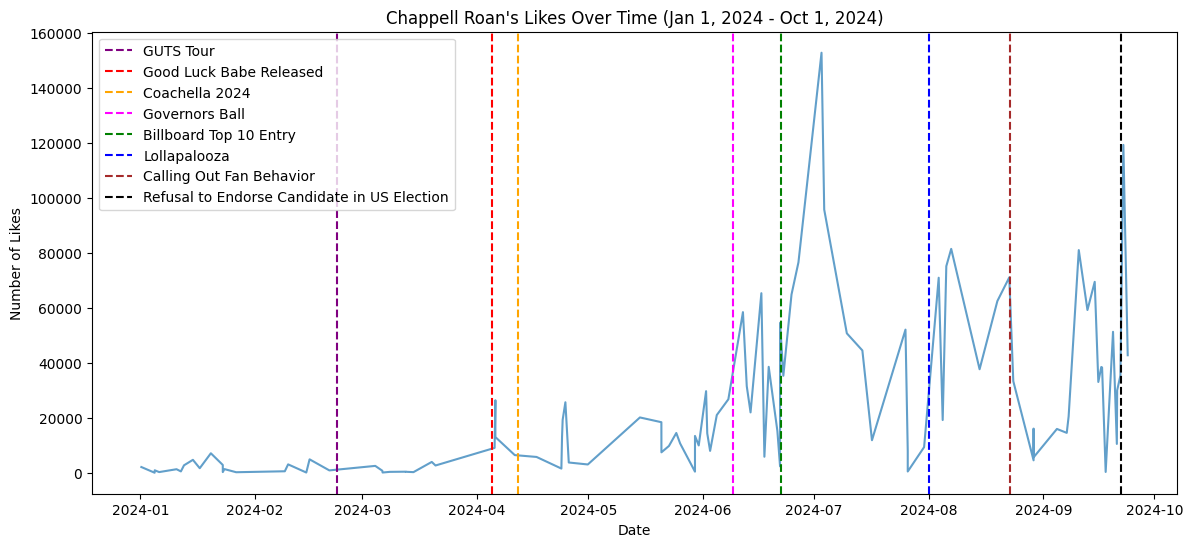

In [ ]:

# filter tweets for the desired date range
start_date = pd.to_datetime('2024-01-01', utc=True)
end_date = pd.to_datetime('2024-10-01', utc=True)
filtered_tweets = chappell_tweets[(chappell_tweets['date'] >= start_date) & (chappell_tweets['date'] <= end_date)]

# sort by date for proper time series plotting
filtered_tweets = filtered_tweets.sort_values('date')

plt.figure(figsize=(14, 6))
#plotting the tweets
plt.plot(filtered_tweets['date'], filtered_tweets['likes'], marker='', linestyle='-', markersize=4, alpha=0.7)
#adding vertical lines for each notable date
plt.axvline(pd.to_datetime('2024-02-23', utc=True), color='purple', linestyle='--', label='GUTS Tour')
plt.axvline(pd.to_datetime('2024-04-05', utc=True), color='red', linestyle='--', label='Good Luck Babe Released')
plt.axvline(pd.to_datetime('2024-04-12', utc=True), color='orange', linestyle='--', label='Coachella 2024')
plt.axvline(pd.to_datetime('2024-06-09', utc=True), color='magenta', linestyle='--', label='Governors Ball')
plt.axvline(pd.to_datetime('2024-06-22', utc=True), color='green', linestyle='--', label='Billboard Top 10 Entry')
plt.axvline(pd.to_datetime('2024-08-01', utc=True), color='blue', linestyle='--', label='Lollapalooza')
plt.axvline(pd.to_datetime('2024-08-23', utc=True), color='brown', linestyle='--', label='Calling Out Fan Behavior')
plt.axvline(pd.to_datetime('2024-09-22', utc=True), color='black', linestyle='--', label='Refusal to Endorse Candidate in US Election')


#titles and formatting
plt.title("Chappell Roan's Likes Over Time (Jan 1, 2024 - Oct 1, 2024)")
plt.xlabel("Date")
plt.ylabel("Number of Likes")
plt.legend()
plt.grid(False)
plt.show()

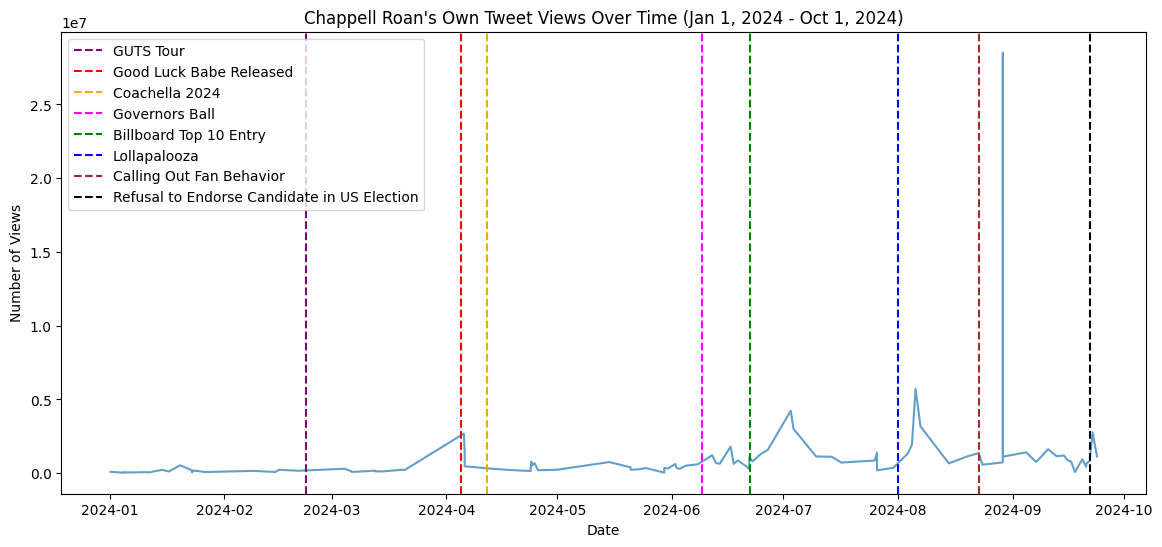

In [ ]:
#same thing for tweet impressions

plt.figure(figsize=(14, 6))
#plotting the tweets
plt.plot(filtered_tweets['date'], filtered_tweets['views'], marker='', linestyle='-', markersize=4, alpha=0.7)

#adding vertical lines for each notable date
plt.axvline(pd.to_datetime('2024-02-23', utc=True), color='purple', linestyle='--', label='GUTS Tour')
plt.axvline(pd.to_datetime('2024-04-05', utc=True), color='red', linestyle='--', label='Good Luck Babe Released')
plt.axvline(pd.to_datetime('2024-04-12', utc=True), color='orange', linestyle='--', label='Coachella 2024')
plt.axvline(pd.to_datetime('2024-06-09', utc=True), color='magenta', linestyle='--', label='Governors Ball')
plt.axvline(pd.to_datetime('2024-06-22', utc=True), color='green', linestyle='--', label='Billboard Top 10 Entry')
plt.axvline(pd.to_datetime('2024-08-01', utc=True), color='blue', linestyle='--', label='Lollapalooza')
plt.axvline(pd.to_datetime('2024-08-23', utc=True), color='brown', linestyle='--', label='Calling Out Fan Behavior')
plt.axvline(pd.to_datetime('2024-09-22', utc=True), color='black', linestyle='--', label='Refusal to Endorse Candidate in US Election')
#titles and formatting
plt.title("Chappell Roan's Own Tweet Views Over Time (Jan 1, 2024 - Oct 1, 2024)")
plt.xlabel("Date")
plt.ylabel("Number of Views")
plt.legend()
plt.grid(False)
plt.show()

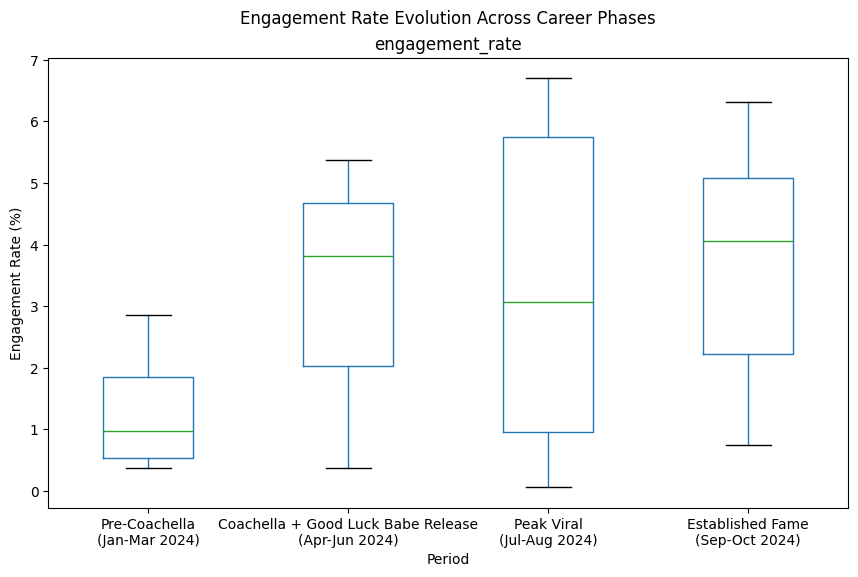

In [ ]:
#gonna try an engagement rate to see how engagement quality changed as she got more famous

engagement_rate = (chappell_tweets['likes'] + chappell_tweets['retweets'] + chappell_tweets['replies'])/chappell_tweets['views']*100

#visualizing using box plot?
def categorize_period(date):
    if date < pd.to_datetime('2024-04-01', utc=True):
        return 'Pre-Coachella\n(Jan-Mar 2024)'
    elif date < pd.to_datetime('2024-07-01', utc=True):
        return 'Coachella + Good Luck Babe Release\n(Apr-Jun 2024)'
    elif date < pd.to_datetime('2024-09-01', utc=True):
        return 'Peak Viral\n(Jul-Aug 2024)'
    else:
        return 'Established Fame\n(Sep-Oct 2024)'

chappell_tweets['period'] = chappell_tweets['date'].apply(categorize_period)
chappell_tweets['engagement_rate'] = ((chappell_tweets['likes'] + chappell_tweets['retweets'] + chappell_tweets['replies']) / chappell_tweets['views']) * 100

# define the chronological order of periods
period_order = [
    'Pre-Coachella\n(Jan-Mar 2024)',
    'Coachella + Good Luck Babe Release\n(Apr-Jun 2024)',
    'Peak Viral\n(Jul-Aug 2024)',
    'Established Fame\n(Sep-Oct 2024)'
]

# convert the 'period' column to an ordered categorical type
chappell_tweets['period'] = pd.Categorical(chappell_tweets['period'], categories=period_order, ordered=True)

#box plot
fig, ax = plt.subplots(figsize=(10, 6))

#titles and axis and formats
chappell_tweets.boxplot(column='engagement_rate', by='period', ax=ax, grid=False)
plt.suptitle('Engagement Rate Evolution Across Career Phases')
plt.xlabel('Period')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=0)
plt.grid(False)
plt.show()

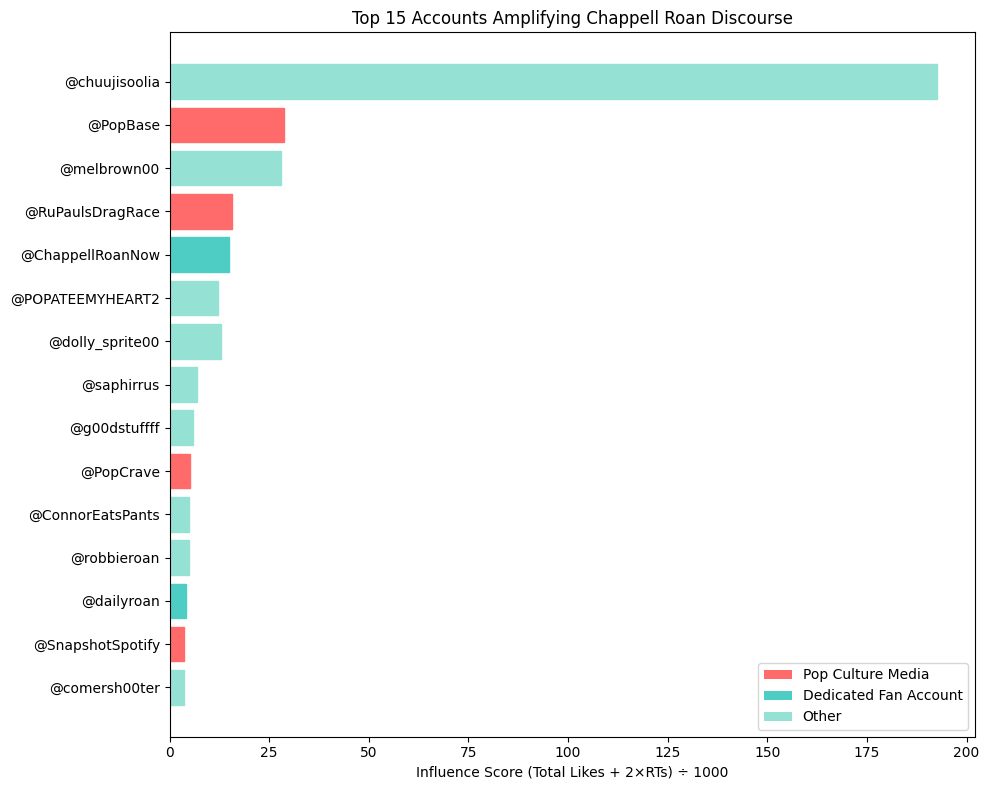

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get top accounts by total engagement generated
top_amplifiers = clean_tweets.groupby('author').agg({
    'tweet_id': 'count',
    'likes': 'sum',
    'retweets': 'sum',
    'author_followers': 'first',
    'author_name': 'first'
}).sort_values('likes', ascending=False).head(15)

top_amplifiers.columns = ['Tweet Count', 'Total Likes', 'Total RTs', 'Followers', 'Display Name']

# Calculate influence score
top_amplifiers['influence_score'] = (
    top_amplifiers['Total Likes'] +
    top_amplifiers['Total RTs'] * 2
) / 1000

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_amplifiers))

bars = ax.barh(y_pos, top_amplifiers['influence_score'])

# Color by account type (you can manually flag these)
colors = []
for account in top_amplifiers.index:
    if account in ['PopCrave', 'PopBase', 'BuzzingPop','SnapshotSpotify', 'RuPaulsDragRace']:
        colors.append('#FF6B6B')  # Red for pop culture aggregators
    elif account in ['dailyroan', 'chappellroanbr', 'ChappellRoanFr', 'ChappellRoanNow']:
        colors.append('#4ECDC4')  # Teal for fan accounts
    else:
        colors.append('#95E1D3')  # Light teal for others

for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"@{name}" for name in top_amplifiers.index])
ax.invert_yaxis()
ax.set_xlabel('Influence Score (Total Likes + 2×RTs) ÷ 1000')
ax.set_title('Top 15 Accounts Amplifying Chappell Roan Discourse')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='Pop Culture Media'),
    Patch(facecolor='#4ECDC4', label='Dedicated Fan Account'),
    Patch(facecolor='#95E1D3', label='Other')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()

In [ ]:
from nltk.corpus import stopwords

# Base English stop words
base_stops = set(stopwords.words('english'))

custom_stops = {
    'chappell', 'roan', 'roans', 'popbase', 'chappellroan', 'chappel',
    'url', 'www', 'link', 'ig', 'fb', 'faq', 'dm', 'moots',
    'chartdata', 'alert', 'ppl', 'people', 'lol'
}


# Add more aggressive filtering for visual word frequency stuff
visual_stops = base_stops.union(custom_stops).union({
    # Time references that clutter word clouds
    'today', 'yesterday', 'ago', 'day', 'week', 'month', 'year',
    'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',

    # Twitter meta-language
    'tweet', 'twitter', 'via', 'rt', 'retweet', 'thread', 'post',

    # Vague intensifiers (these don't tell us anything meaningful)
    'really', 'literally', 'actually', 'like', 'just', 'still', 'even', 'pls',

    # Fan account filler
   'update', 'news', 'via', 'source', 'video', 'photo', 'image',

    # Pronouns (if they're dominating your word cloud)
    'im', 'ive', 'youre', 'shes', 'hes', 'theyre', 'weve',

    # Numbers and punctuation artifacts
    '1', '2', '3', '10', '2024', '2025', '2026',

    # Common but meaningless words in this context
    'get', 'got', 'getting', 'gonna', 'wanna', 'gotta',
    'one', 'two', 'first', 'second', 'next',
    'make', 'makes', 'made', 'making',
    'thing', 'things', 'time', 'times',
    'way', 'need', 'needs', 'know', 'think','chart', 'would','also','right',

    # If you have fan accounts in your data
    'daily', 'dailyroan', 'brasil', 'france', 'updates',
})


In [ ]:
mining_clean_tweets = clean_tweets.copy(deep=True)

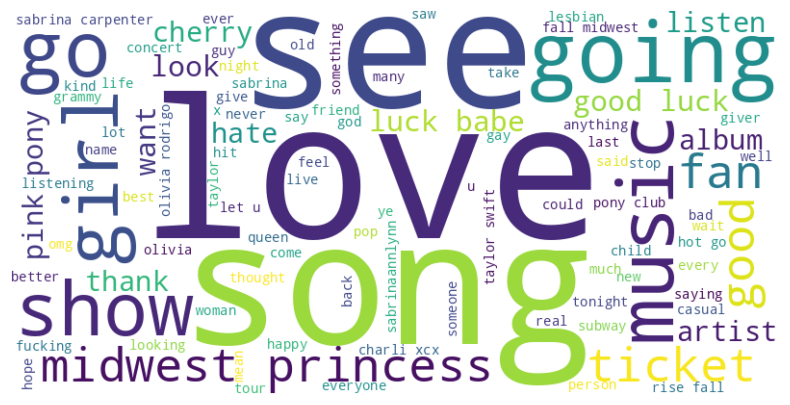

In [ ]:
#word map https://www.geeksforgeeks.org/python/generating-word-cloud-python/

#https://www.datacamp.com/datalab/w/9eb69cab-4cf8-4972-a764-17f25673fbd3/

#https://gist.github.com/sebleier/554280

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_prepared_text = ' '.join(full_list_tweets['prepared_text'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis',stopwords=visual_stops, max_words=100).generate(all_prepared_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

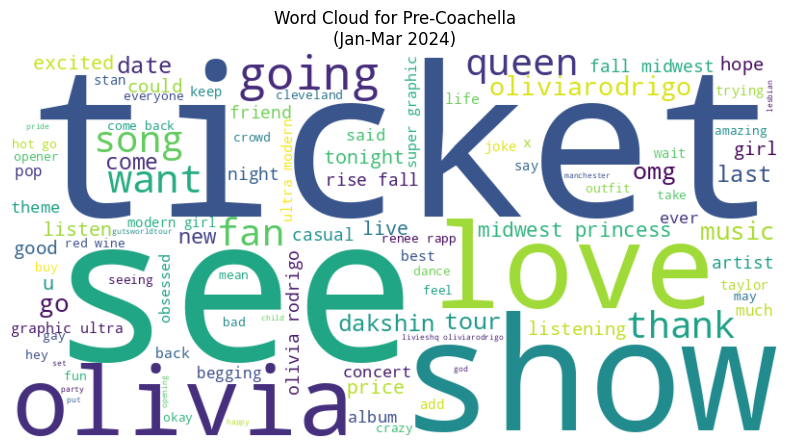

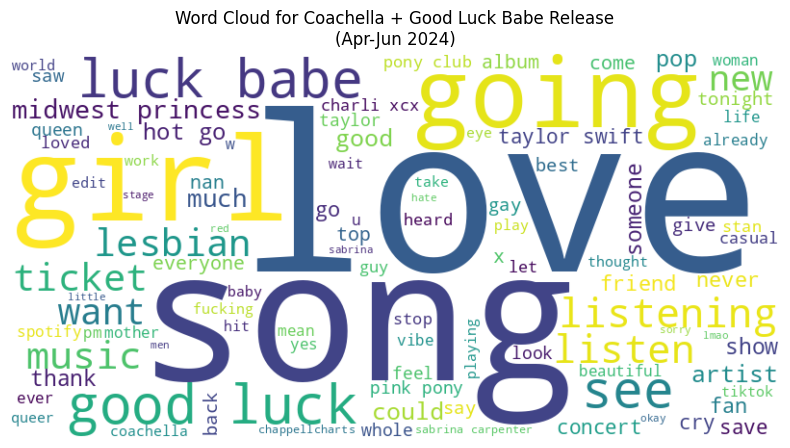

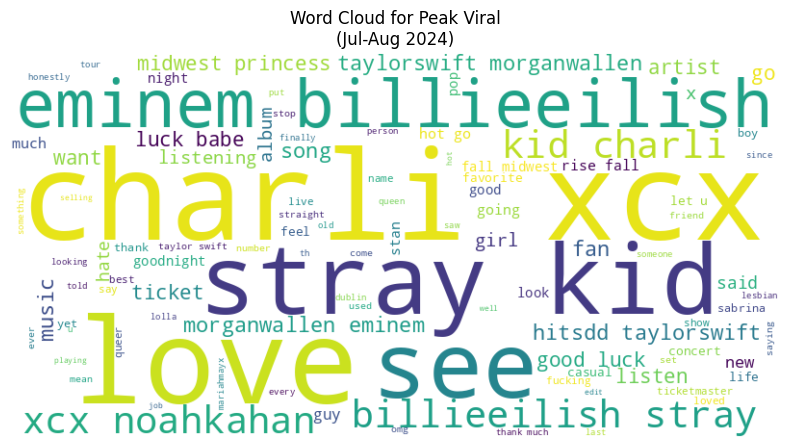

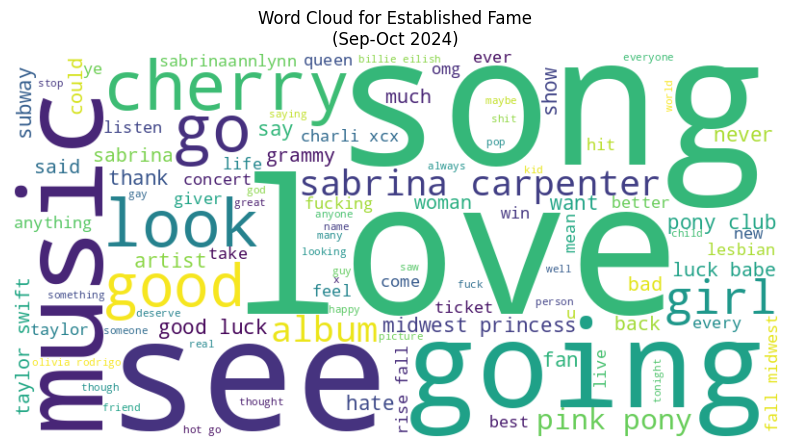

In [ ]:
# Re-apply the categorization to clean_tweets as it might have been modified
def categorize_period(date):
    if date < pd.to_datetime('2024-04-01', utc=True):
        return 'Pre-Coachella\n(Jan-Mar 2024)'
    elif date < pd.to_datetime('2024-07-01', utc=True):
        return 'Coachella + Good Luck Babe Release\n(Apr-Jun 2024)'
    elif date < pd.to_datetime('2024-09-01', utc=True):
        return 'Peak Viral\n(Jul-Aug 2024)'
    else:
        return 'Established Fame\n(Sep-Oct 2024)'

clean_tweets['period'] = clean_tweets['date'].apply(categorize_period)

# Get unique periods in the desired order
period_order = [
    'Pre-Coachella\n(Jan-Mar 2024)',
    'Coachella + Good Luck Babe Release\n(Apr-Jun 2024)',
    'Peak Viral\n(Jul-Aug 2024)',
    'Established Fame\n(Sep-Oct 2024)'
]

# Loop through each period and generate a word cloud
for period in period_order:
    # Filter tweets for the current period
    period_tweets = clean_tweets[clean_tweets['period'] == period]

    # Concatenate all prepared text for the current period
    all_prepared_text_period = ' '.join(period_tweets['prepared_text'].astype(str))

    # Generate word cloud only if there's text available for the period
    if all_prepared_text_period.strip():
        wordcloud_period = WordCloud(width=800, height=400, background_color='white', colormap='viridis', stopwords=visual_stops, max_words=100).generate(all_prepared_text_period)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_period, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for {period}')
        plt.show()
    else:
        print(f"No tweets found for the period: {period}. Skipping word cloud generation.")

In [ ]:
from collections import Counter

word_counter = Counter()


for row in mining_clean_tweets.to_dict(orient='records'):
    # ensure 'prepared_text' is a string before splitting
    if isinstance(row['prepared_text'], str):
        word_counter.update(row['prepared_text'].split())

most_common= word_counter.most_common(10)

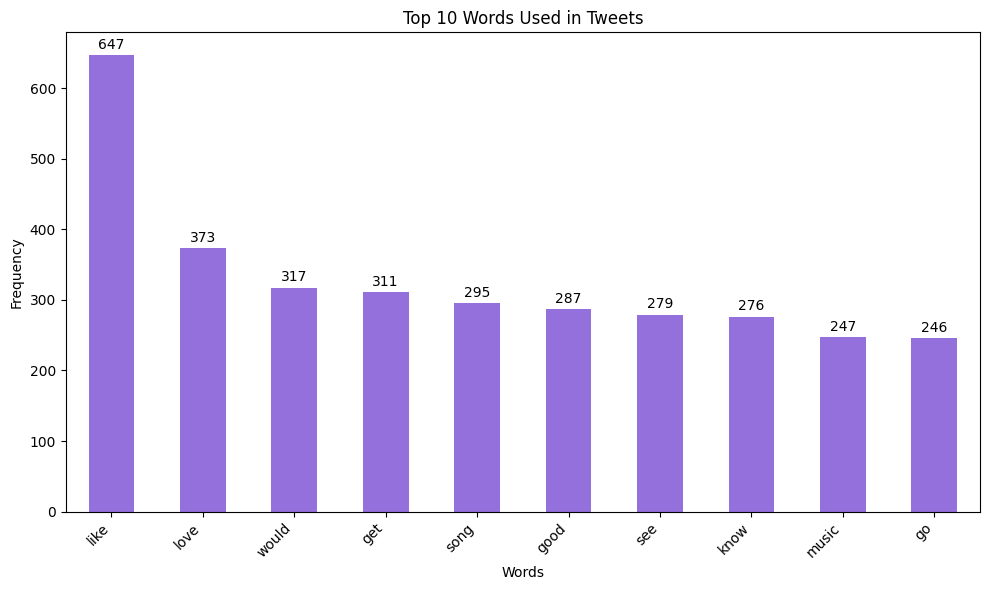

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# convert the list of tuples to a pandas Series for plotting
plot_data = pd.Series(dict(most_common))

# create the bar plot and get the axes object
ax = plot_data.plot(kind='bar', color='#9370DB', figsize=(10, 6))
plt.title('Top 10 Words Used in Tweets')
plt.xlabel('Words')
plt.ylabel('Frequency')

# add exact numbers above each bar
for i, v in enumerate(plot_data.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom') # Adjust v+5 to control vertical position

plt.grid(False)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# ***3. Text Mining***

In [ ]:
import nltk
from collections import Counter
from nltk.util import ngrams

# Initialize lists to hold all tokens, bigrams, and trigrams
all_tokens = []
all_bigrams = []
all_trigrams = []

# Iterate through each prepared_text entry and tokenize it
for text in clean_tweets['prepared_text']:
    if isinstance(text, str) and text.strip(): # Ensure it's a valid string
        tokens = nltk.word_tokenize(text)
        all_tokens.extend(tokens)

        # Generate bigrams and trigrams
        all_bigrams.extend(list(ngrams(tokens, 2)))
        all_trigrams.extend(list(ngrams(tokens, 3)))

# Count frequencies
bigram_freq = Counter(all_bigrams)
trigram_freq = Counter(all_trigrams)

print("\nMost Common Bigrams:")
for bigram, count in bigram_freq.most_common(15):
    print(f"{bigram[0]}_{bigram[1]}: {count}")

print("\nMost Common Trigrams:")
for trigram, count in trigram_freq.most_common(15):
    print(f"{trigram[0]}_{trigram[1]}_{trigram[2]}: {count}")


Most Common Bigrams:
midwest_princess: 147
good_luck: 135
luck_babe: 128
pink_pony: 114
sabrina_carpenter: 109
charli_xcx: 108
pony_club: 106
taylor_swift: 97
rise_fall: 82
fall_midwest: 81
hot_go: 79
olivia_rodrigo: 69
let_u: 53
billie_eilish: 49
feel_like: 41

Most Common Trigrams:
good_luck_babe: 128
pink_pony_club: 105
fall_midwest_princess: 81
rise_fall_midwest: 80
billieeilish_stray_kid: 32
eminem_billieeilish_stray: 31
stray_kid_charli: 31
kid_charli_xcx: 31
charli_xcx_noahkahan: 31
best_new_artist: 29
hitsdd_taylorswift_morganwallen: 29
taylorswift_morganwallen_eminem: 29
morganwallen_eminem_billieeilish: 29
red_wine_supernova: 24
super_graphic_ultra: 19


In [ ]:
import nltk
from nltk.collections import *
tokens = nltk.wordpunct_tokenize(all_prepared_text)
bigrams = nltk.bigrams(tokens)
trigrams = nltk.trigrams(tokens)

freq_bigrams = nltk.FreqDist(bigrams)
freq_trigrams = nltk.FreqDist(trigrams)

In [ ]:
freq_bigrams.most_common(10)

[(('midwest', 'princess'), 147),
 (('good', 'luck'), 135),
 (('luck', 'babe'), 128),
 (('pink', 'pony'), 114),
 (('sabrina', 'carpenter'), 109),
 (('charli', 'xcx'), 108),
 (('pony', 'club'), 106),
 (('taylor', 'swift'), 97),
 (('rise', 'fall'), 82),
 (('fall', 'midwest'), 81)]

In [ ]:
bigrams=pd.DataFrame(freq_bigrams.most_common(15), columns=['Bigram', 'Frequency'])
bigrams


,Bigram,Frequency
0,"(midwest, princess)",147
1,"(good, luck)",135
2,"(luck, babe)",128
3,"(pink, pony)",114
4,"(sabrina, carpenter)",109
5,"(charli, xcx)",108
6,"(pony, club)",106
7,"(taylor, swift)",97
8,"(rise, fall)",82
9,"(fall, midwest)",81


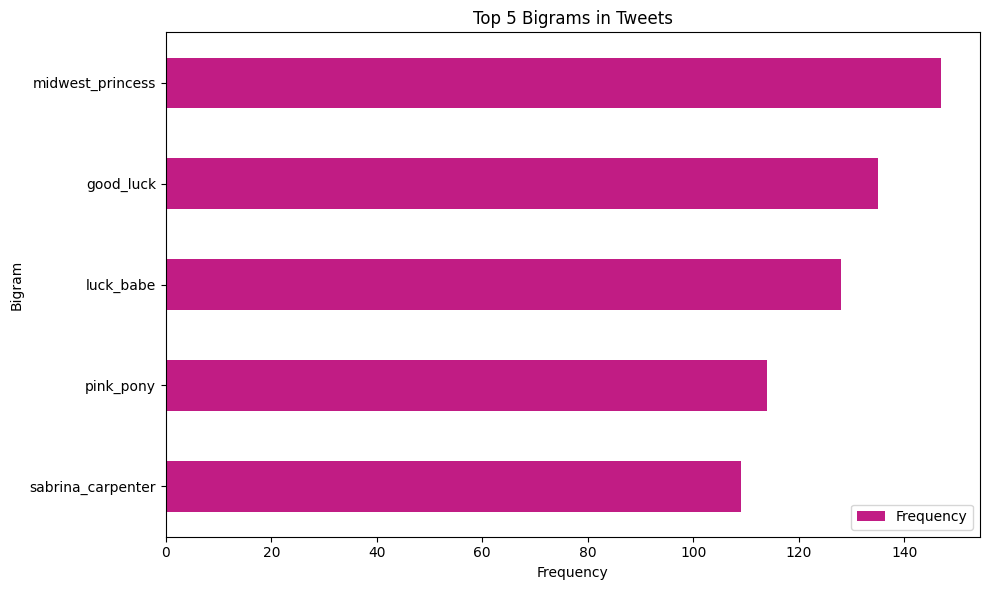

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# create bigrams df
bigrams_to_plot = pd.DataFrame(freq_bigrams.most_common(5), columns=['Bigram', 'Frequency'])
bigrams_to_plot['Bigram'] = bigrams_to_plot['Bigram'].apply(lambda x: '_'.join(x))

# sort the df in ascending order
bigrams_to_plot = bigrams_to_plot.sort_values(by='Frequency', ascending=True)

#plot
bigrams_to_plot.plot(x='Bigram', y='Frequency', kind='barh', figsize=(10, 6), color='#C11C84')

plt.title('Top 5 Bigrams in Tweets')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
freq_trigrams.most_common(10)

[(('good', 'luck', 'babe'), 128),
 (('pink', 'pony', 'club'), 105),
 (('fall', 'midwest', 'princess'), 81),
 (('rise', 'fall', 'midwest'), 80),
 (('billieeilish', 'stray', 'kid'), 32),
 (('eminem', 'billieeilish', 'stray'), 31),
 (('stray', 'kid', 'charli'), 31),
 (('kid', 'charli', 'xcx'), 31),
 (('charli', 'xcx', 'noahkahan'), 31),
 (('best', 'new', 'artist'), 29)]

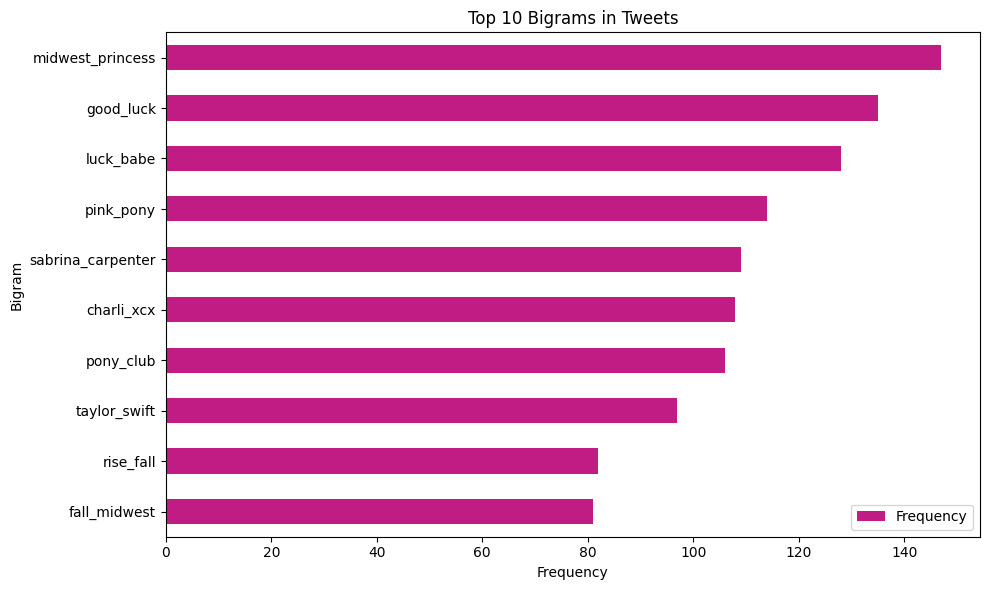

In [ ]:
# Re-create the bigrams DataFrame to ensure it's not a generator
top10_bigrams_to_plot = pd.DataFrame(freq_bigrams.most_common(10), columns=['Bigram', 'Frequency'])
top10_bigrams_to_plot['Bigram'] = top10_bigrams_to_plot['Bigram'].apply(lambda x: '_'.join(x))

# Sort the DataFrame in ascending order of frequency to make the most frequent appear at the top of a barh chart
top10_bigrams_to_plot = top10_bigrams_to_plot.sort_values(by='Frequency', ascending=True)

top10_bigrams_to_plot.plot(x='Bigram', y='Frequency', kind='barh', figsize=(10, 6), color='#C11C84')

plt.title('Top 10 Bigrams in Tweets')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.grid(False)
plt.tight_layout()
plt.show()

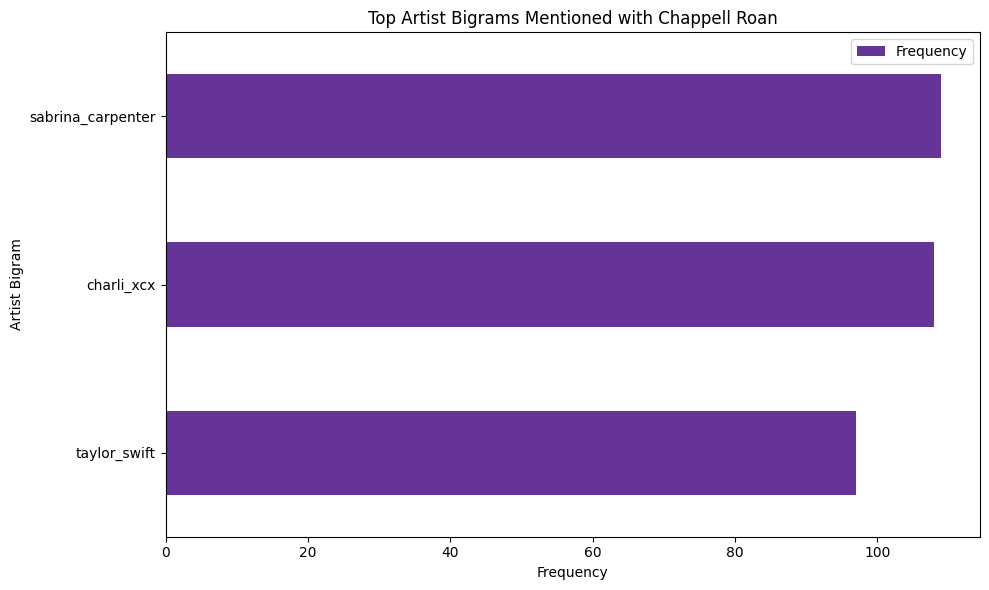

In [ ]:
artist_names = ['sabrina_carpenter', 'charli_xcx', 'taylor_swift', 'olivia_rodrigo', 'billie_eilish']

# filter to include only artist names
artist_bigrams = top10_bigrams_to_plot[top10_bigrams_to_plot['Bigram'].isin(artist_names)]

# sort in ascending order
artist_bigrams = artist_bigrams.sort_values(by='Frequency', ascending=True)

# plotting
artist_bigrams.plot(x='Bigram', y='Frequency', kind='barh', figsize=(10, 6), color='#663399')

plt.title('Top Artist Bigrams Mentioned with Chappell Roan')
plt.xlabel('Frequency')
plt.ylabel('Artist Bigram')
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
#noun phrase extraction
nltk.download('brown')
nltk.download('punkt')

from collections import Counter
from textblob import TextBlob

noun_counter = Counter()

for tweet in clean_tweets['prepared_text'].to_list():
  # Check if the tweet is a string before processing
  if isinstance(tweet, str):
    blob = TextBlob(tweet)
    noun_counter.update(blob.noun_phrases)

for np in noun_counter.most_common(20):
  print(np)

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


('pink pony club', 56)
('good luck babe', 34)
('rise fall midwest princess', 24)
('super graphic ultra', 18)
('midwest princess', 18)
('new artist', 16)
('favorite artist', 15)
('red wine supernova', 14)
('new song', 13)
('olivia rodrigo', 11)
('sabrina carpenter', 10)
('modern girl', 10)
('culture fan', 9)
('luck babe', 8)
('full episode', 7)
('charli xcx', 7)
('security guard', 7)
('te amo', 7)
('new photo', 7)
('short n sweet', 7)


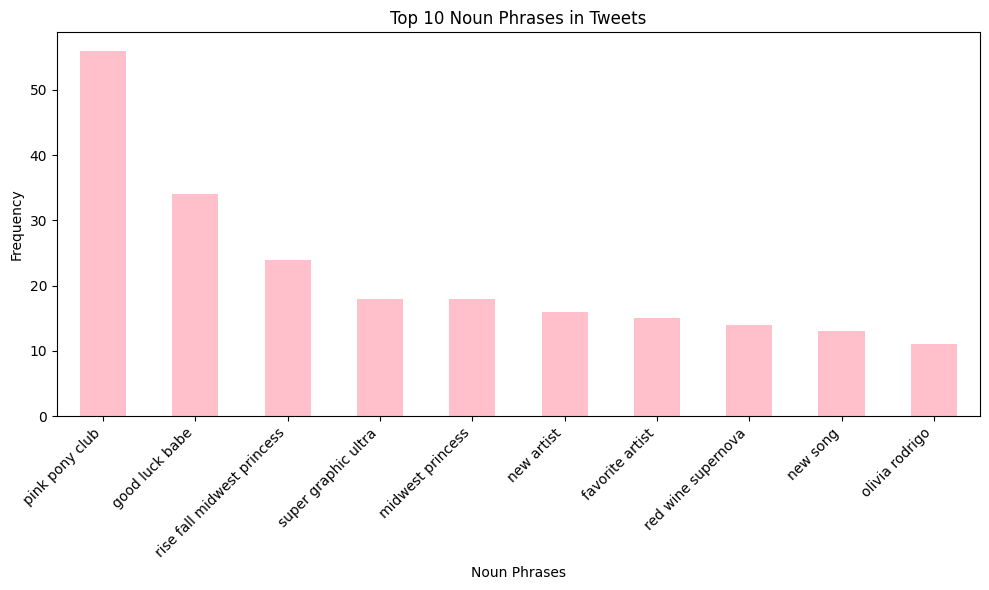

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get the top 20 noun phrases and format them for the word cloud
top_20_noun_phrases = pd.Series(dict(noun_counter.most_common(10)))


top_20_noun_phrases.plot(kind='bar', color='pink', figsize=(10, 6))
plt.title('Top 10 Noun Phrases in Tweets')
plt.xlabel('Noun Phrases')
plt.ylabel('Frequency')

for i, v in enumerate(top_20_noun_phrases.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom') # Adjust v+5 to control vertical position

plt.grid(False)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


In [ ]:
#LDA
!pip install gensim
import gensim
import gensim.corpora as corpora
from pprint import pprint

In [ ]:
documents = [t.split() for t in clean_tweets['prepared_text'] if isinstance(t, str)]
vocab = corpora.Dictionary(documents)
corpus = [vocab.doc2bow(text) for text in documents]

num_topics = 7
lda_model = gensim.models.LdaMulticore(corpus=corpus, id2word=vocab, num_topics=num_topics)

pprint(lda_model.print_topics())

[(0,
  '0.026*"princess" + 0.026*"midwest" + 0.013*"rise" + 0.013*"fall" + '
  '0.007*"artist" + 0.005*"charli" + 0.005*"love" + 0.005*"good" + 0.005*"xcx" '
  '+ 0.005*"see"'),
 (1,
  '0.015*"taylorswift" + 0.014*"like" + 0.012*"love" + 0.008*"ladygaga" + '
  '0.007*"pop" + 0.006*"new" + 0.006*"sabrina" + 0.006*"hot" + 0.006*"go" + '
  '0.006*"get"'),
 (2,
  '0.011*"midwest" + 0.010*"princess" + 0.008*"song" + 0.008*"love" + '
  '0.008*"cherry" + 0.007*"good" + 0.007*"go" + 0.007*"need" + 0.006*"fall" + '
  '0.006*"way"'),
 (3,
  '0.010*"would" + 0.009*"love" + 0.007*"know" + 0.007*"like" + '
  '0.006*"princess" + 0.006*"much" + 0.006*"thank" + 0.006*"midwest" + '
  '0.006*"album" + 0.006*"see"'),
 (4,
  '0.015*"shakira" + 0.009*"girl" + 0.008*"like" + 0.007*"one" + 0.006*"drake" '
  '+ 0.006*"subway" + 0.006*"album" + 0.005*"going" + 0.005*"popcrave" + '
  '0.004*"see"'),
 (5,
  '0.012*"like" + 0.007*"rollingstone" + 0.006*"get" + 0.005*"know" + '
  '0.005*"make" + 0.005*"want" + 0.0

In [ ]:
pd.DataFrame(lda_model.print_topics(), columns=['Topic', 'Words'])

,Topic,Words
0,0,"0.026*""princess"" + 0.026*""midwest"" + 0.013*""ri..."
1,1,"0.015*""taylorswift"" + 0.014*""like"" + 0.012*""lo..."
2,2,"0.011*""midwest"" + 0.010*""princess"" + 0.008*""so..."
3,3,"0.010*""would"" + 0.009*""love"" + 0.007*""know"" + ..."
4,4,"0.015*""shakira"" + 0.009*""girl"" + 0.008*""like"" ..."
5,5,"0.012*""like"" + 0.007*""rollingstone"" + 0.006*""g..."
6,6,"0.011*""theweeknd"" + 0.008*""ladygaga"" + 0.008*""..."


In [ ]:
display(pd.DataFrame(lda_model.print_topics(), columns=['Topic', 'Words']))

,Topic,Words
0,0,"0.008*""year"" + 0.007*""know"" + 0.006*""yes"" + 0...."
1,1,"0.009*""midwest"" + 0.009*""album"" + 0.009*""princ..."
2,2,"0.036*""midwest"" + 0.036*""princess"" + 0.018*""fa..."
3,3,"0.014*""would"" + 0.009*""cherry"" + 0.007*""love"" ..."
4,4,"0.018*""like"" + 0.010*""shakira"" + 0.010*""thewee..."
5,5,"0.010*""love"" + 0.007*""one"" + 0.006*""omg"" + 0.0..."
6,6,"0.015*""ladygaga"" + 0.009*""beyonce"" + 0.009*""li..."
7,7,"0.020*""taylorswift"" + 0.016*""rollingstone"" + 0..."


In [ ]:
clean_tweets

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text,period
0,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en,really really want like like take potent...,Pre-Coachella\n(Jan-Mar 2024)
1,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en,guy give recs pretty,Pre-Coachella\n(Jan-Mar 2024)
2,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en,really said heard like magic got wand r...,Pre-Coachella\n(Jan-Mar 2024)
3,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en,onlythebella could get olivia ticket like...,Pre-Coachella\n(Jan-Mar 2024)
4,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en,buy ticket cleveland,Pre-Coachella\n(Jan-Mar 2024)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6820,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en,marenyearly drivcmycar baby weird,Established Fame\n(Sep-Oct 2024)
6821,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en,boygeorge irrelevant,Established Fame\n(Sep-Oct 2024)
6822,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en,thorswdn boygeorge thought unwanted attent...,Established Fame\n(Sep-Oct 2024)
6823,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en,boygeorge thank george awesome take guy,Established Fame\n(Sep-Oct 2024)


In [ ]:
import numpy as np

nltk.download('vader_lexicon')

# Add Stan Twitter / pop culture slang to the lexicon
stan_twitter_lexicon = {
    # Positive slang
    'slay': 4.0,
    'slaying': 4.0,
    'slayed': 4.0,
    'serve': 3.5,
    'serving': 3.5,
    'served': 3.5,
    'ate': 4.0,
    'eating': 4.0,
    'iconic': 3.5,
    'queen': 3.0,
    'mother': 3.5,
    'legend': 3.0,
    'talented': 3.0,
    'unbothered': 2.5,
    'obsessed': 3.0,
    'obsession': 3.0,
    'period': 2.5,  # "she said what she said period"
    'purr': 2.5,
    'yup': 2.0,
    'yes': 2.0,
    'deserve': 2.5,
    'deserves': 2.5,
    'goat': 3.5,  # greatest of all time
    'snapped': 3.5,
    'bodied': 3.5,
    'demolished': 3.5,  # in positive context
    'devoured': 3.5,
    'cleared': 3.0,
    'understood': 2.5,  # "understood the assignment"
    'assignment': 2.5,

    # Negative slang
    'flop': -3.0,
    'flopped': -3.0,
    'cringe': -2.5,
    'overrated': -3.0,
    'overhyped': -2.5,
    'annoying': -2.5,
    'corny': -2.0,
    'corniest': -2.0,
    'mid': -2.0,  # "mediocre"
    'washed': -2.5,
    'fraud': -3.0,
    'ratio': -2.0,  # getting ratioed = bad
    'cancelled': -3.0,
    'yikes': -2.0,
    'ick': -2.0,

    # Context-dependent (default to positive in pop stan context)
    'dead': 2.0,  # "im dead" = laughing
    'dying': 2.0,
    'screaming': 2.5,
    'crying': 2.0,  # crying tears of joy usually
    'obsessed': 3.0,
    'insane': 2.5,  # "this is insane" = amazing
    'crazy': 2.0,
    'sick': 2.0,  # "this is sick" = cool
    'kill': 2.0,  # "she killed it"
    'murdered': 2.5,
    'destroyed': 2.5,
}

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Update VADER's lexicon with the custom stan_twitter_lexicon
sia.lexicon.update(stan_twitter_lexicon)

df = clean_tweets.copy()

def score(row):
  text = row['text']
  if isinstance(text, str) and text.strip():
    return sia.polarity_scores(text)['compound']

df['sentiment'] = df.apply(score,axis=1)
df

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text,period,sentiment
0,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en,really really want like like take potent...,Pre-Coachella\n(Jan-Mar 2024),0.5127
1,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en,guy give recs pretty,Pre-Coachella\n(Jan-Mar 2024),0.7488
2,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en,really said heard like magic got wand r...,Pre-Coachella\n(Jan-Mar 2024),0.4215
3,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en,onlythebella could get olivia ticket like...,Pre-Coachella\n(Jan-Mar 2024),0.7579
4,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en,buy ticket cleveland,Pre-Coachella\n(Jan-Mar 2024),0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6820,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en,marenyearly drivcmycar baby weird,Established Fame\n(Sep-Oct 2024),0.0000
6821,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en,boygeorge irrelevant,Established Fame\n(Sep-Oct 2024),0.0000
6822,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en,thorswdn boygeorge thought unwanted attent...,Established Fame\n(Sep-Oct 2024),-0.6514
6823,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en,boygeorge thank george awesome take guy,Established Fame\n(Sep-Oct 2024),0.7840


In [ ]:
def categorize_sentiment(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_category'] = df['sentiment'].apply(categorize_sentiment)
df

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text,period,sentiment,sentiment_category
0,1751648893056544891,https://x.com/bl00dyrainebow/status/1751648893...,2024-01-28 16:50:14+00:00,bl00dyrainebow,add your name,342,yall i really really want to like Chappell Roa...,2,0,1,157,en,really really want like like take potent...,Pre-Coachella\n(Jan-Mar 2024),0.5127,positive
1,1749994298760712285,https://x.com/G00DTITSBIGHRT/status/1749994298...,2024-01-24 03:15:28+00:00,G00DTITSBIGHRT,avery ౨ৎ,2674,guys!!! give me chappell roan recs pretty please,0,0,1,174,en,guy give recs pretty,Pre-Coachella\n(Jan-Mar 2024),0.7488,positive
2,1748505484770836637,https://x.com/Br00TaLDaN/status/17485054847708...,2024-01-20 00:39:27+00:00,Br00TaLDaN,Danny THEE Haunted 👻 Himbo 💪🏼,18236,Chappell Roan really said \n\nI heard you like...,10,1,1,1058,en,really said heard like magic got wand r...,Pre-Coachella\n(Jan-Mar 2024),0.4215,positive
3,1762911985006530850,https://x.com/S00BIED00/status/176291198500653...,2024-02-28 18:45:45+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,@OnlyTheBella28 i couldn’t get olivia tickets ...,1,0,0,56,en,onlythebella could get olivia ticket like...,Pre-Coachella\n(Jan-Mar 2024),0.7579,positive
4,1762910866096148520,https://x.com/S00BIED00/status/176291086609614...,2024-02-28 18:41:18+00:00,S00BIED00,tayceratops ૮ ․ _․ ྀིა,3705,do i buy chappell roan tickets for cleveland???,1,0,2,454,en,buy ticket cleveland,Pre-Coachella\n(Jan-Mar 2024),0.0000,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6820,2035460128162410682,https://x.com/shwnxtd00r/status/20354601281624...,2026-03-21 20:54:46+00:00,shwnxtd00r,.,94,@marenyearly @drivcmycar baby you’re weird… @C...,4,0,0,1961,en,marenyearly drivcmycar baby weird,Established Fame\n(Sep-Oct 2024),0.0000,neutral
6821,2033876219406536941,https://x.com/BlobbyBlobs00/status/20338762194...,2026-03-17 12:00:52+00:00,BlobbyBlobs00,watching the insanity,368,@BoyGeorge @ChappellRoan You are irrelevant,0,0,0,9,en,boygeorge irrelevant,Established Fame\n(Sep-Oct 2024),0.0000,neutral
6822,2031466558229205271,https://x.com/andsoitgoes00/status/20314665582...,2026-03-10 20:25:44+00:00,andsoitgoes00,C ❤️‍🔥,26,@thorswdn @BoyGeorge @ChappellRoan She should ...,67,0,2,1978,en,thorswdn boygeorge thought unwanted attent...,Established Fame\n(Sep-Oct 2024),-0.6514,negative
6823,2031464831128043619,https://x.com/goodtogo00/status/20314648311280...,2026-03-10 20:18:53+00:00,goodtogo00,Remix,497,@BoyGeorge @ChappellRoan Thank you George this...,0,0,0,79,en,boygeorge thank george awesome take guy,Established Fame\n(Sep-Oct 2024),0.7840,positive


sentiment_category
positive    3171
neutral     2473
negative    1181
Name: count, dtype: int64


<Axes: xlabel='sentiment_category'>

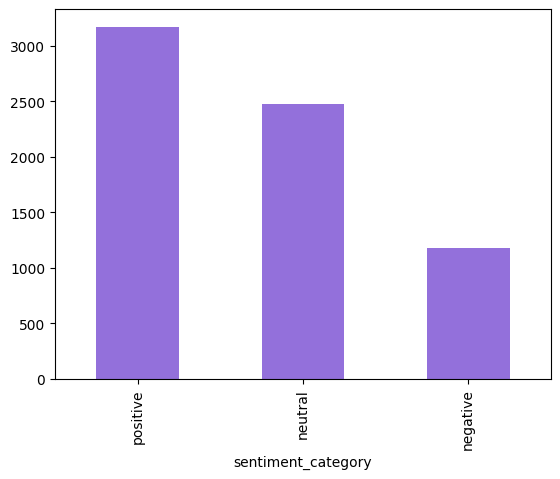

In [ ]:
print(df['sentiment_category'].value_counts())

df['sentiment_category'].value_counts().plot(kind= 'bar', color= '#9370DB')

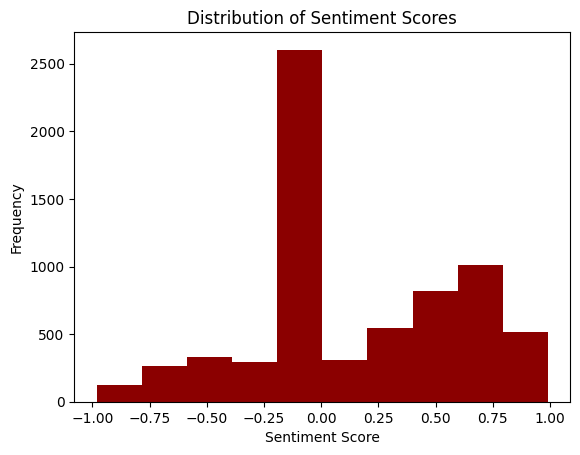

In [ ]:
df['sentiment'].plot(kind='hist', color='#8B0000')

plot = plt.title('Distribution of Sentiment Scores')
plot = plt.xlabel('Sentiment Score')
plot = plt.ylabel('Frequency')
plot = plt.grid(False)


In [ ]:
df.sort_values(by='sentiment', ascending=False).head(10)

,tweet_id,tweet_url,date,author,author_name,author_followers,text,likes,retweets,replies,views,lang,prepared_text,period,sentiment,sentiment_category
4982,1865120266038206775,https://x.com/bennylftv/status/186512026603820...,2024-12-06 19:44:58+00:00,bennylftv,ben✷,2967,@cherry_roan @ChappellRoan YES IT IS BABY HAPP...,1,0,1,37,en,cherry yes baby happiest birthday love d...,Established Fame\n(Sep-Oct 2024),0.9905,positive
3128,1885113528186556655,https://x.com/sumisdumb/status/188511352818655...,2025-01-30 23:51:03+00:00,sumisdumb,summer 🐾,175,@PopBase aoty - ttpd or hmhas\nbest new artis...,1,0,0,71,en,aoty ttpd hmhas best new artist soty go...,Established Fame\n(Sep-Oct 2024),0.9895,positive
3173,1885106564190920811,https://x.com/dimzykdl/status/1885106564190920811,2025-01-30 23:23:23+00:00,dimzykdl,‏َ,264,JE PENSE : \naoty : cowboy carter \nsoty : goo...,2,0,7,1136,en,je pense aoty cowboy carter soty good l...,Established Fame\n(Sep-Oct 2024),0.9883,positive
3158,1885108821485314468,https://x.com/shortndifficult/status/188510882...,2025-01-30 23:32:21+00:00,shortndifficult,sonia,1314,@PopBase album of the year: hit me hard and so...,1,0,0,243,en,album year hit hard soft song year bird...,Established Fame\n(Sep-Oct 2024),0.9842,positive
3070,1873879959133126680,https://x.com/TechBuzzRecap/status/18738799591...,2024-12-30 23:52:51+00:00,TechBuzzRecap,TechBuzzRecap,63,𝐁𝐁𝐂 𝐑𝐚𝐝𝐢𝐨 𝟏 𝐔𝐧𝐯𝐞𝐢𝐥𝐬 𝟐𝟎𝟐𝟒 𝐀𝐧𝐭𝐡𝐞𝐦 \nAccording to...,0,0,0,114,en,according report daily mail sabrina carpe...,Established Fame\n(Sep-Oct 2024),0.9758,positive
4659,1840519798922653843,https://x.com/pinkvelopes/status/1840519798922...,2024-09-29 22:31:29+00:00,pinkvelopes,mal,183,THE SERVE AFTER SERVE... i love a queen who pa...,30,8,1,1433,en,serve serve love queen pay homage icon ...,Established Fame\n(Sep-Oct 2024),0.9714,positive
6309,2044074790319693847,https://x.com/JonahVCG/status/2044074790319693847,2026-04-14 15:26:21+00:00,JonahVCG,Tu Veneka,1575,And people still says that hate doesn't sells....,0,0,0,130,en,still say hate sell also still say quee...,Established Fame\n(Sep-Oct 2024),0.9694,positive
1030,1896362457918324967,https://x.com/Ruthness00/status/18963624579183...,2025-03-03 00:50:17+00:00,Ruthness00,Ruth Elijah,3,@ShannonGaitz @Chappells_Show I love Monday re...,1,0,1,62,en,shannongaitz chappells show love monday r...,Established Fame\n(Sep-Oct 2024),0.9687,positive
6465,1783057623526285342,https://x.com/Hollykach00/status/1783057623526...,2024-04-24 08:57:19+00:00,Hollykach00,harry showed me his titty,256,@ChappellRoan @itsallegrad would slay the hous...,2,0,0,86,en,itsallegrad would slay house boot yasss ...,Coachella + Good Luck Babe Release\n(Apr-Jun 2...,0.9682,positive
6405,1822696243778187358,https://x.com/purple_stoner00/status/182269624...,2024-08-11 18:07:03+00:00,purple_stoner00,The Purple Girl💜|| Doechii Stan🤍🐊,19,@ChappellRoanNow After Midnight and Super Grap...,0,0,0,17,en,midnight super graphic ultra modern girl ...,Peak Viral\n(Jul-Aug 2024),0.9682,positive


In [ ]:
true_neutral_tweets=df[(df['sentiment']== 0.0)]

In [ ]:
true_neutral_tweets.to_csv('true neutrals.csv')